# MIVA-KNIGHT-RL: Complete Algorithm Implementation (CREMA-D / Pipeline D)
## Reinforcement Learning-Driven Multimodal Robot Control
### Deep Q-Network · Experience Replay · NLP Feedback · Emotion-Conditioned Reward

**Author:** Oluwakayode (Kayode) Soyinka | IT 581 Capstone | Concordia University of Edmonton  
**Supervisor:** Dr. Baidya Saha

---

This notebook is a **CREMA-D companion** to `MIVA_KNIGHT_RL_Implementation.ipynb`. It keeps the **same 13 algorithms** and cell structure, but replaces the abstract **speech / body / hand** sub-classifier with **Pipeline D** components:

- **Audio:** 768-d Wav2Vec features from `crema_cache.pt` → `AudioProjection` (768→512), matching `MIVA_KNIGHT_PipelineD_CREMAD_Annotated_fixed.ipynb`
- **Video:** middle frame tensor `[3,224,224]` → `VideoFrameProjection` (ResNet-50 → 512), same notebook
- **Operator emotion (Algorithm 8 & 13):** uses the **six CREMA-D emotions** (`angry`, `disgust`, `fearful`, `happy`, `neutral`, `sad`) as in Pipeline D Phase 2/3

The **DQN loop** (Algorithms 3–12) stays on the same discrete **toy grid environment**; only the **perception module** (Algorithms 1–2) and **emotion tables** are CREMA-aligned.

### Real CREMA data (Algorithms 1–2)
Requires **`crema_cache.pt`** plus **`audio_projection_cremad.pth`** and **`video_frame_projection.pth`** on the project Drive (or `MIVA_PROJECT_BASE`). No synthetic cache tensors or random-init projection weights.

### Finding your project folder (Colab)
Setup uses **`find_project_base()`** like **`MIVA_KNIGHT_PipelineD_CREMAD_Annotated_fixed.ipynb`**, plus a **MyDrive scan** if the folder name differs. Set **`MIVA_PROJECT_BASE`** to the folder that contains **`models/`** and **`Data/`** if auto-detect fails.

### Algorithms Implemented
| # | Algorithm | Notes in this notebook |
|---|---|---|
| 1 | Sub-Classifier Forward Pass | Audio + video → fused → discrete state |
| 2 | Sub-Classifier Training Loop | Real `crema_cache.pt` clips only (no synthetic fallback) |
| 3–12 | (unchanged logic) | ε-greedy, replay, DQN, DDQN, Dueling |
| 13 | Emotion-Conditioned Reward | CREMA-6 emotion bonus table |


## 0. Environment Setup

### Mathematical foundations

**Definition (MDP):** A Markov Decision Process is a 5-tuple $\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{T}, \mathcal{R}, \gamma)$ where:
- $\mathcal{S}$: state space   
- $\mathcal{A}$: discrete action space  
- $\mathcal{T}: \mathcal{S}\times\mathcal{A}\to\Delta(\mathcal{S})$: transition function  
- $\mathcal{R}: \mathcal{S}\times\mathcal{A}\to\mathbb{R}$: reward function  
- $\gamma\in[0,1)$: discount factor

**Axiom (Markov Property):**
$$P(s_{t+1}\mid s_t, a_t, s_{t-1}, a_{t-1},\ldots) = P(s_{t+1}\mid s_t, a_t)$$
The future depends only on the present, not the history.

**Definition (Q-function and Bellman Optimality):**
$$Q^*(s,a) = \mathbb{E}\!\left[r + \gamma\max_{a'}Q^*(s',a')\,\bigg|\,s,a\right]$$

**Definition (DQN):** Replace the tabular $Q$ with a neural network $Q_\theta(s,a)\approx Q^*(s,a)$.

**Axiom (Deadly Triad):** Function approximation + bootstrapping + off-policy sampling can diverge. DQN mitigates this with: ① experience replay, ② target network, ③ gradient clipping.

### Plain language
We're building a robot brain that learns by trial and error — like a child learning to walk. Every time the robot tries an action, it records what happened. A neural network learns to predict how good each action is in each situation. Three tricks keep learning stable: saving old memories (replay), using a "frozen snapshot" for comparison (target network), and limiting how big each learning step can be (gradient clipping).

In [1]:
import math, random, copy, time, os
from collections import deque, namedtuple, defaultdict
from typing import List, Tuple, Dict, Optional, NamedTuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

# ── Reproducibility ────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── PyTorch 2.6 patch: apply once (safe if cells re-run) ─────
if getattr(torch, '_miva_original_load', None) is None:
    torch._miva_original_load = torch.load

def _patched_torch_load(f, *a, **kw):
    kw.setdefault('weights_only', False)
    return torch._miva_original_load(f, *a, **kw)

torch.load = _patched_torch_load


def find_project_base():
    """Same discovery as MIVA_KNIGHT_PipelineD_CREMAD_Annotated_fixed.ipynb (Cell 3)."""
    env = os.environ.get('MIVA_PROJECT_BASE', '').strip()
    if env and os.path.isdir(env) and os.path.isdir(os.path.join(env, 'models')):
        return env
    possible = [
        '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project ',
        '/content/drive/MyDrive/Oluwakayode Soyinka IT 581 Project',
    ]
    shortcut_root = '/content/drive/.shortcut-targets-by-id'
    if os.path.exists(shortcut_root):
        for sid in os.listdir(shortcut_root):
            sp = os.path.join(shortcut_root, sid)
            if os.path.isdir(sp):
                for folder in os.listdir(sp):
                    if 'soyinka' in folder.lower() or '581' in folder.lower():
                        possible.append(os.path.join(sp, folder))
    for path in possible:
        if os.path.exists(path) and os.path.exists(os.path.join(path, 'models')):
            return path
    mydrive = '/content/drive/MyDrive'
    if os.path.isdir(mydrive):
        best = None
        for name in sorted(os.listdir(mydrive)):
            p = os.path.join(mydrive, name)
            if not os.path.isdir(p):
                continue
            if not os.path.isdir(os.path.join(p, 'models')):
                continue
            cache_pt = os.path.join(p, 'Data', 'crema_embeddings_cache', 'crema_cache.pt')
            if os.path.isfile(cache_pt):
                return p
            if best is None:
                best = p
        if best is not None:
            return best
    return None


try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Note: not in Colab — set MIVA_PROJECT_BASE if needed.')

PROJECT_BASE = find_project_base()

if PROJECT_BASE:
    CACHE_FILE = os.path.join(PROJECT_BASE, 'Data', 'crema_embeddings_cache', 'crema_cache.pt')
    PIPELINE_D_DIR = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineD')
    AUDIO_PROJ_PATH = os.path.join(PIPELINE_D_DIR, 'audio_projection_cremad.pth')
    VIDEO_PROJ_PATH = os.path.join(PIPELINE_D_DIR, 'video_frame_projection.pth')
else:
    CACHE_FILE = PIPELINE_D_DIR = AUDIO_PROJ_PATH = VIDEO_PROJ_PATH = None

CREMA_EMOTIONS_6 = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
CREMA_EMOTION_TO_LABEL = {e: i for i, e in enumerate(CREMA_EMOTIONS_6)}

EMBED_DIM    = 512
WAV2VEC_DIM  = 768
N_ACTIONS    = 6
N_STATES     = 16
GAMMA        = 0.99
LR           = 1e-4
BATCH_SIZE   = 32
BUFFER_CAP   = 5_000
TARGET_C     = 100
EPS_START    = 1.0
EPS_MIN      = 0.01
EPS_DECAY    = 5e-3
WARMUP_STEPS = 200
N_EPISODES   = 300
MAX_STEPS_EP = 50

ACTION_NAMES = ['move_forward','turn_left','turn_right','pick_up','wave','stop']

def _require_real_crema_assets():
    if not PROJECT_BASE or not os.path.isdir(PROJECT_BASE):
        raise RuntimeError(
            'PROJECT_BASE not found. Mount Drive or set MIVA_PROJECT_BASE (see Pipeline D notebooks).'
        )
    if not CACHE_FILE or not os.path.isfile(CACHE_FILE):
        raise RuntimeError(f'Real CREMA cache missing: {CACHE_FILE}')
    if not AUDIO_PROJ_PATH or not os.path.isfile(AUDIO_PROJ_PATH):
        raise RuntimeError(f'Real weights missing: {AUDIO_PROJ_PATH}')
    if not VIDEO_PROJ_PATH or not os.path.isfile(VIDEO_PROJ_PATH):
        raise RuntimeError(f'Real weights missing: {VIDEO_PROJ_PATH}')
    ck = torch.load(CACHE_FILE, map_location='cpu')
    if len(ck) < 32:
        raise RuntimeError(f'crema_cache.pt has only {len(ck)} entries; need >= 32.')
    s0 = next(iter(ck.values()))
    if s0['audio_emb'].shape[-1] != 768:
        raise RuntimeError('Cache audio_emb must be 768-d.')
    return ck

crema_cache = _require_real_crema_assets()
print(f'Loaded real crema_cache.pt: {len(crema_cache):,} clips')

print(f'Device       : {DEVICE}')
print(f'Action space : {N_ACTIONS}  {ACTION_NAMES}')
print(f'State space  : {N_STATES}')
print(f'Buffer cap   : {BUFFER_CAP}')
print(f'PROJECT_BASE : {PROJECT_BASE}')


Mounted at /content/drive
Loaded real crema_cache.pt: 7,442 clips
Device       : cuda
Action space : 6  ['move_forward', 'turn_left', 'turn_right', 'pick_up', 'wave', 'stop']
State space  : 16
Buffer cap   : 5000
PROJECT_BASE : /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project 


## System Architecture Flowchart

The complete MIVA-KNIGHT-RL closed-loop system (from the thesis Figure 1):

```
╔══════════════════════════════════════════════════════════════════════╗
║                      MIVA-KNIGHT-RL CONTROL LOOP                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  ┌─────────┐   speech  ┌────────────────┐        ┌─────────────┐   ║
║  │  Human  │──body ───►│ Sub-classifier │──S ────►│    Robot    │   ║
║  │Operator │──hand ───►│  f_φ(·)        │        │  exec(i_t)  │   ║
║  └────┬────┘           └────────────────┘        └──────┬──────┘   ║
║       │ feedback_speech    NLP Feedback ◄─────────────── │(s,i,s',i',r)║
║       │ Motions            Module       ◄─────────────── │           ║
║       │                                                  ▼           ║
║       │                                          ┌───────────────┐  ║
║       │                                          │ Replay Buffer │  ║
║       │                                          │    B ring     │  ║
║       │                                          └───────┬───────┘  ║
║       │                                                  │ sample   ║
║       │            ┌─────────────────────────────────────▼──────┐  ║
║       │            │  DQN LEARNING LOOP                          │  ║
║       │            │  Q-target(θ⁻) ──Y──► Huber Loss ◄──Q-eval  │  ║
║       │            │       ↑ replace every C steps    │ update θ │  ║
║       │            └────────────────────────────────────────────┘  ║
╚══════════════════════════════════════════════════════════════════════╝
```

**Plain language:** Think of the system like a student (robot) learning from a teacher (reward signal). The student tries actions, records the outcomes in a notebook (replay buffer), periodically reviews random pages from the notebook (mini-batch), and updates its mental model (Q-network). A "photo" of the mental model is taken periodically (target network) so the student doesn't compare its current understanding to a moving target.

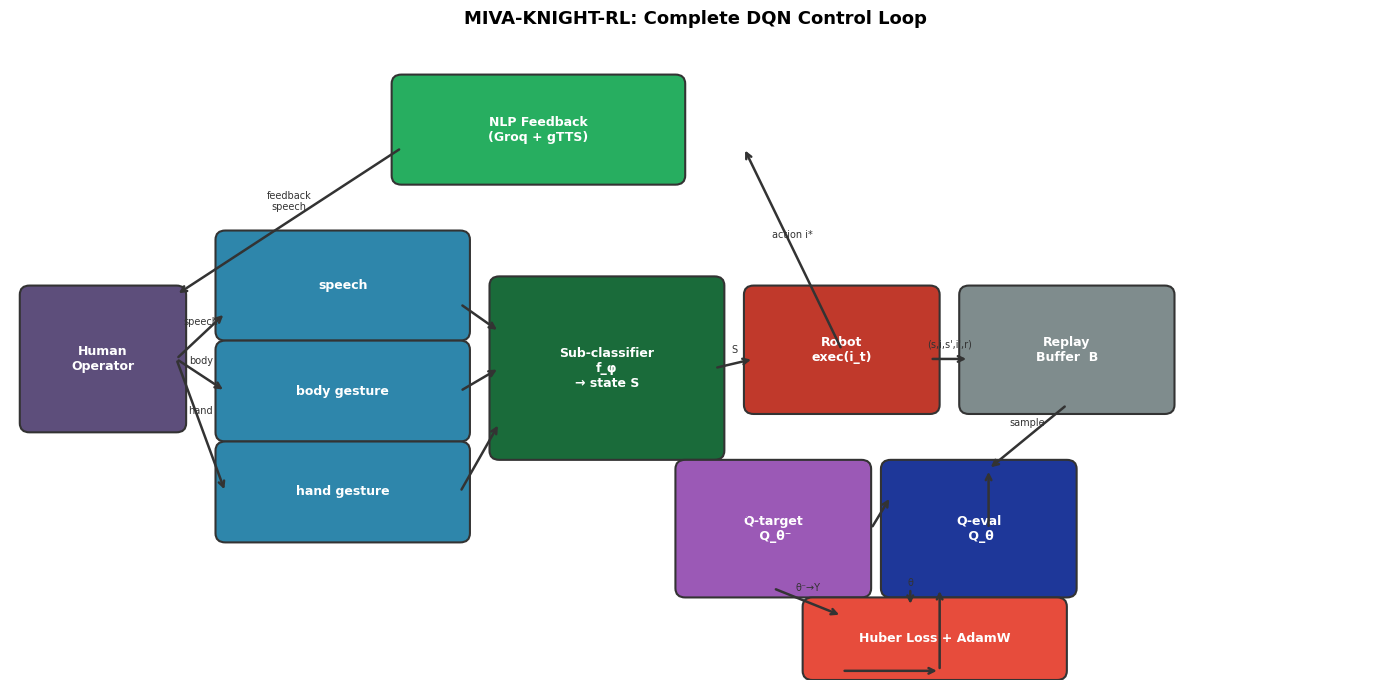

In [2]:
# Draw the architecture flowchart using matplotlib
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')
ax.set_facecolor('#f8f9fa')

def box(ax, x, y, w, h, label, color='#4a90d9', fontsize=9):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                 facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label='', color='#333'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.12, label, fontsize=7, ha='center', color=color)

# Boxes
box(ax,  0.2, 2.8, 1.5, 1.4, 'Human\nOperator', '#5d4e7b')
box(ax,  2.2, 3.8, 2.4, 1.0, 'speech', '#2e86ab')
box(ax,  2.2, 2.7, 2.4, 0.9, 'body gesture', '#2e86ab')
box(ax,  2.2, 1.6, 2.4, 0.9, 'hand gesture', '#2e86ab')
box(ax,  5.0, 2.5, 2.2, 1.8, 'Sub-classifier\nf_φ\n→ state S', '#1a6b3a')
box(ax,  7.6, 3.0, 1.8, 1.2, 'Robot\nexec(i_t)', '#c0392b')
box(ax,  9.8, 3.0, 2.0, 1.2, 'Replay\nBuffer  B', '#7f8c8d')
box(ax,  9.0, 1.0, 1.8, 1.3, 'Q-eval\n Q_θ', '#1e3799')
box(ax,  6.9, 1.0, 1.8, 1.3, 'Q-target\n Q_θ⁻', '#9b59b6')
box(ax,  8.2, 0.1, 2.5, 0.7, 'Huber Loss + AdamW', '#e74c3c')
box(ax,  4.0, 5.5, 2.8, 1.0, 'NLP Feedback\n(Groq + gTTS)', '#27ae60')

# Arrows
arrow(ax, 1.7, 3.5, 2.2, 4.0, 'speech')
arrow(ax, 1.7, 3.5, 2.2, 3.15, 'body')
arrow(ax, 1.7, 3.5, 2.2, 2.05, 'hand')
arrow(ax, 4.6, 4.1, 5.0, 3.8); arrow(ax, 4.6, 3.15, 5.0, 3.4); arrow(ax, 4.6, 2.05, 5.0, 2.8)
arrow(ax, 7.2, 3.4, 7.6, 3.5, 'S')
arrow(ax, 9.4, 3.5, 9.8, 3.5, '(s,i,s\',i\',r)')
arrow(ax, 10.8, 3.0, 10.0, 2.3, 'sample')
arrow(ax, 10.0, 1.65, 10.0, 2.3)
arrow(ax, 8.8, 1.65, 9.0, 2.0)
arrow(ax, 9.2, 1.0, 9.2, 0.8, 'θ')
arrow(ax, 7.8, 1.0, 8.5, 0.7, 'θ⁻→Y')
arrow(ax, 8.5, 0.1, 9.5, 0.1); arrow(ax, 9.5, 0.1, 9.5, 1.0)
arrow(ax, 7.9, 1.65, 6.9, 1.65, 'Replace θ⁻←θ', '#9b59b6')
arrow(ax, 8.5, 3.6, 7.5, 5.8, 'action i*')
arrow(ax, 4.0, 5.8, 1.7, 4.2, 'feedback\nspeech')

ax.set_title('MIVA-KNIGHT-RL: Complete DQN Control Loop', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()

## Algorithm 1 — Sub-Classifier Forward Pass: CREMA-D Audio + Video → State

### Technical description

**Definition (CREMA Sub-Classifier $f_\phi$):**
$$f_\phi : \mathbb{R}^{768} \times \mathbb{R}^{3\times224\times224} \to \mathcal{S}, \quad |\mathcal{S}| = N_S$$

**Step 1 — Pipeline D encoders (same as `PipelineD_CREMAD_Annotated_fixed`):**
$$\hat{e}_a = P_a^{\text{CREMA}}(x_{\text{audio}}) \in \mathbb{S}^{511}, \quad
  \hat{e}_v = P_v^{\text{CREMA}}(x_{\text{frame}}) \in \mathbb{S}^{511}$$

**Step 2 — Fuse:**
$$c = [\hat{e}_a;\, \hat{e}_v] \in \mathbb{R}^{1024}, \qquad
  e_{\text{fused}} = \text{LN}(W_f c + b_f) \in \mathbb{R}^{512}$$

**Step 3 — Discrete state:**
$$\text{logits} = W_c e_{\text{fused}} + b_c \in \mathbb{R}^{N_S}, \qquad S = \arg\max(\text{logits})$$

```
audio_emb [768] ──► AudioProjection ──► ê_a ─┐
frame [3,224,224] ─► VideoFrameProjection ─► ê_v ─┤── concat[1024] ─► LN ─► FC ─► S
```

### Plain language
The robot’s “situation label” $S$ is inferred from **what it hears** (Wav2Vec features) and **what it sees** (one middle frame per CREMA-D clip), trained together like Pipeline D — not from abstract body/hand skeletons.


In [3]:
# Algorithm 1 & 2: CREMA-D Sub-Classifier (forward + training scaffold)
# ---------------------------------------------------------------------------

class AudioProjection(nn.Module):
    """Pipeline D — 768 → 512, L2-normalised (CREMA-D)."""
    def __init__(self, wav2vec_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim),
            nn.GELU(),
            nn.LayerNorm(wav2vec_dim),
            nn.Linear(wav2vec_dim, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)


class VideoFrameProjection(nn.Module):
    """Pipeline D — ResNet-50 frozen + head to 512."""
    def __init__(self, embed_dim=512, freeze_backbone=True):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.GELU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, images):
        with torch.no_grad():
            feat = self.backbone(images).flatten(1)
        return F.normalize(self.norm(self.proj(feat)), p=2, dim=1)


class CremaMultimodalSubClassifier(nn.Module):
    """
    Algorithm 1: f_φ — audio_emb + video frame → discrete state S.
    """
    def __init__(self, embed_dim=EMBED_DIM, n_states=N_STATES):
        super().__init__()
        self.audio_proj = AudioProjection(WAV2VEC_DIM, embed_dim)
        self.video_proj = VideoFrameProjection(embed_dim, freeze_backbone=True)
        self.fusion_fc = nn.Linear(2 * embed_dim, embed_dim)
        self.fusion_ln = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, n_states)

    def forward(self, x_audio: torch.Tensor, x_frame: torch.Tensor):
        e_a = self.audio_proj(x_audio)
        e_v = self.video_proj(x_frame)
        c = torch.cat([e_a, e_v], dim=-1)
        e_fused = self.fusion_ln(self.fusion_fc(c))
        logits = self.classifier(e_fused)
        S = logits.argmax(dim=-1)
        return S, logits, e_fused


# Load Pipeline D weights (required — validated in setup cell)
subclf = CremaMultimodalSubClassifier().to(DEVICE)
ck = torch.load(AUDIO_PROJ_PATH, map_location=DEVICE)
sd = ck.get('model_state_dict', ck)
subclf.audio_proj.load_state_dict(sd, strict=True)
print('Loaded AudioProjection from audio_projection_cremad.pth')

ck = torch.load(VIDEO_PROJ_PATH, map_location=DEVICE)
sd = ck.get('model_state_dict', ck)
subclf.video_proj.load_state_dict(sd, strict=False)
print('Loaded VideoFrameProjection from video_frame_projection.pth')

# Freeze backbones / optional: train only fusion + classifier in Alg 2
for p in subclf.audio_proj.parameters():
    p.requires_grad = True
for p in subclf.video_proj.backbone.parameters():
    p.requires_grad = False
for p in subclf.video_proj.proj.parameters():
    p.requires_grad = True
for p in subclf.video_proj.norm.parameters():
    p.requires_grad = True

_k = list(crema_cache.keys())[:4]
x_a = torch.stack([crema_cache[k]['audio_emb'] for k in _k]).to(DEVICE)
x_f = torch.stack([crema_cache[k]['frame_tensor'] for k in _k]).to(DEVICE)
S_demo, logits_demo, e_fused_demo = subclf(x_a, x_f)
n_params = sum(p.numel() for p in subclf.parameters())
print(f'[Alg 1] CREMA Sub-classifier | States: {S_demo.tolist()} | e_fused: {e_fused_demo.shape} | params: {n_params:,}')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s]


Loaded AudioProjection from audio_projection_cremad.pth
Loaded VideoFrameProjection from video_frame_projection.pth
[Alg 1] CREMA Sub-classifier | States: [3, 15, 15, 3] | e_fused: torch.Size([4, 512]) | params: 27,654,992


## Algorithm 2 — Sub-Classifier Training Loop

### Technical description

**Training objective (cross-entropy):**
$$\mathcal{L}_{\text{clf}} = -\frac{1}{N}\sum_{n=1}^N \log P(S = y_n \mid x_{\text{audio}}^{(n)}, x_{\text{frame}}^{(n)};\ \phi)$$

where:
$$P(S = j \mid \cdot) = \text{softmax}(W_c e_{\text{fused}})_j$$

**AdamW update (thesis §9):**
$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$
$$\theta_{t+1} = \theta_t - \eta\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon} - \eta\lambda\theta_t \qquad (\text{decoupled weight decay})$$

**Gradient clipping:** $\tilde{\nabla}_\phi = \min\!\left(1, \frac{c}{\|\nabla_\phi\|}\right)\nabla_\phi$, $c = 1.0$

### Plain language
Training the sub-classifier is like teaching a student to recognise situations. We show it thousands of labelled examples (CREMA audio + video frame → correct state), compute how wrong its guesses are (cross-entropy loss), and nudge its parameters in the direction that reduces the error. Gradient clipping ensures the nudge is never too big (no wild jumps).


=== Algorithm 2: CREMA Sub-Classifier Training ===
  Data: real crema_cache.pt clips only
  Epoch   4/12 | Loss: 1.0430 | Acc: 68.3%
  Epoch   8/12 | Loss: 0.2756 | Acc: 94.4%
  Epoch  12/12 | Loss: 0.1394 | Acc: 97.2%


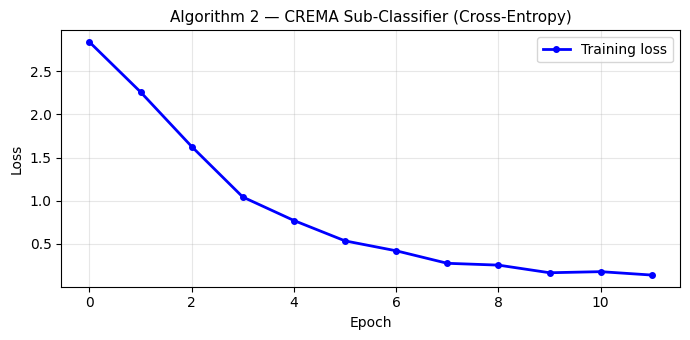

In [4]:
# Algorithm 2: Sub-Classifier Training Loop (CREMA-D features)
# -------------------------------------------------------------

class CremaGestureDataset(Dataset):
    """Real CREMA clips only. Target = hash(emotion, actor_id) mod N_STATES (both from cache)."""
    def __init__(self, n=800, n_states=N_STATES, cache=None):
        if cache is None or len(cache) < 32:
            raise RuntimeError('CremaGestureDataset requires real crema_cache with at least 32 clips.')
        self.n_states = n_states
        self.cache = cache
        keys = list(cache.keys())
        random.seed(SEED)
        random.shuffle(keys)
        self.keys = keys[:min(n, len(keys))]
        self.n = len(self.keys)
        labs = []
        for k in self.keys:
            v = cache[k]
            emo = v['emotion']
            aid = int(v['actor_id'])
            lab = (CREMA_EMOTION_TO_LABEL[emo] * 7 + (aid % 7)) % n_states
            labs.append(lab)
        self.labels = torch.tensor(labs, dtype=torch.long)

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        k = self.keys[i]
        v = self.cache[k]
        return v['audio_emb'], v['frame_tensor'], self.labels[i]


def train_subclassifier(model: CremaMultimodalSubClassifier, n_epochs: int = 12,
                        lr: float = 1e-4, batch_size: int = 32):
    ds = CremaGestureDataset(n=900, cache=crema_cache)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01)
    losses, accs = [], []
    model.train()
    for ep in range(n_epochs):
        ep_loss, correct, total = 0.0, 0, 0
        for x_a, x_f, y in dl:
            x_a, x_f, y = x_a.to(DEVICE), x_f.to(DEVICE), y.to(DEVICE)
            S_pred, logits, _ = model(x_a, x_f)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            correct += (S_pred == y).sum().item()
            total += len(y)
        avg_loss = ep_loss / len(dl)
        acc = correct / total
        losses.append(avg_loss)
        accs.append(acc)
        if (ep + 1) % 4 == 0:
            print(f'  Epoch {ep+1:3d}/{n_epochs} | Loss: {avg_loss:.4f} | Acc: {acc*100:.1f}%')
    return model, losses


print('=== Algorithm 2: CREMA Sub-Classifier Training ===')
print('  Data: real crema_cache.pt clips only')
subclf, clf_losses = train_subclassifier(subclf, n_epochs=12)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(clf_losses, 'b-o', markersize=4, linewidth=2, label='Training loss')
ax.set_title('Algorithm 2 — CREMA Sub-Classifier (Cross-Entropy)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()



## Algorithm 3 — Robot Interaction and Transition Generation

### Technical description

**Definition (ε-greedy policy):**
$$i_t = \begin{cases} \text{random } a \sim \mathcal{A} & \text{with probability } \varepsilon \\ \arg\max_a Q_\theta(S_t, a) & \text{with probability } 1-\varepsilon \end{cases}$$

**Definition (Typed Transition Tuple):**
$$\tau = (s,\; i,\; s',\; i',\; r)$$
- $s$: current state; $i$: action taken; $s'$: next state; $i'$: greedy next action; $r$: reward

**Definition (Composite Reward):**
$$r_t = w_1 r_{\text{task}} + w_2 r_{\text{safety}} + w_3 r_{\text{social}}, \quad \sum w_k = 1$$

**ε-decay:**
$$\varepsilon_t = \max(\varepsilon_{\min},\ \varepsilon_0 \cdot e^{-\lambda_\varepsilon t})$$

```
State s_t ──► Q_θ(s_t,·) ──► [ε-greedy] ──► action i_t
                                                  │
                                                  ▼
                                         Robot executes i_t
                                                  │
                                    ┌─────────────┤
                                    │             ▼
                                 r_t          s_{t+1}
                                    │             │
                                    └─────────────▼
                                          memory.push(s,i,s',i',r)
```

### Plain language
The robot's decision loop: flip a biased coin. If heads (ε chance), pick a random action to *explore* — try something new. If tails, pick the action the neural network thinks is best (*exploit*). Either way, record what happened (state before, action taken, state after, reward) into the memory book. Over time, ε decreases so the robot relies more on its learned knowledge.

In [5]:
# Algorithm 3: Robot Interaction and Transition Generation
# --------------------------------------------------------

# ── Named tuple for typed transition (s, i, s', i', r) ────────
Transition = namedtuple('Transition', ['s', 'i', 's_next', 'i_next', 'r'])


class ToyRobotEnv:
    """
    A lightweight grid-world environment that mimics the MIVA-KNIGHT robot.
    State: int in [0, N_STATES-1].  Actions: see ACTION_NAMES.
    Reward: goal-based + safety penalty.
    """
    GOAL_STATE = N_STATES - 1

    def __init__(self, n_states: int = N_STATES, n_actions: int = N_ACTIONS):
        self.n_states  = n_states
        self.n_actions = n_actions
        # Random transition table T[s][a] = s'  (deterministic proxy)
        rng = np.random.RandomState(SEED)
        self.T = rng.randint(0, n_states, (n_states, n_actions))
        self.state = 0

    def reset(self) -> int:
        self.state = random.randint(0, self.n_states - 2)  # not goal
        return self.state

    def step(self, action: int) -> Tuple[int, float, bool]:
        s_next = int(self.T[self.state, action])
        # Composite reward  r = w1*r_task + w2*r_safety + w3*r_social
        r_task   = 1.0 if s_next == self.GOAL_STATE else -0.01
        r_safety = -1.0 if action == 5 and self.state < 2 else 0.0  # unsafe stop early
        r_social = 0.1 if action in [4]  else 0.0                   # wave bonus
        r = 0.7*r_task + 0.2*r_safety + 0.1*r_social
        done = (s_next == self.GOAL_STATE)
        self.state = s_next
        return s_next, r, done


def robot_interact(state: int, q_eval: nn.Module, eps: float, env: ToyRobotEnv,
                   memory, state_dim: int = N_STATES) -> Tuple[int, Transition]:
    """
    Algorithm 3: ε-greedy action selection, environment step, memory push.

    s_t  →  [ε-greedy Q_θ]  →  i_t  →  env.step  →  (s_{t+1}, r_t)
    →  i_{t+1} = argmax Q_θ(s_{t+1},·)  →  Transition pushed to memory
    """
    # Step 1: ε-greedy action selection
    if random.random() < eps:
        i_t = random.randrange(N_ACTIONS)             # exploration
    else:
        s_tensor = F.one_hot(torch.tensor([state]), state_dim).float().to(DEVICE)
        with torch.no_grad():
            q_vals = q_eval(s_tensor)                  # [1, N_ACTIONS]
        i_t = int(q_vals.argmax(dim=-1).item())        # exploitation

    # Step 2: Execute on environment
    s_next, r_t, done = env.step(i_t)

    # Step 3: Greedy next action (for SARSA-style logging)
    s_next_t = F.one_hot(torch.tensor([s_next]), state_dim).float().to(DEVICE)
    with torch.no_grad():
        q_next = q_eval(s_next_t)
    i_next = int(q_next.argmax(dim=-1).item())

    # Step 4: Store typed transition (s, i, s', i', r)
    tau = Transition(s=state, i=i_t, s_next=s_next, i_next=i_next, r=r_t)
    if memory is not None:
        memory.push(tau)

    return s_next, tau, done


# Demo
env_demo = ToyRobotEnv()
s0 = env_demo.reset()
# Placeholder Q-network for demo
q_demo = nn.Linear(N_STATES, N_ACTIONS).to(DEVICE)
print('=== Algorithm 3: Robot Interaction (demo, no memory yet) ===')
print(f'  Init state: {s0}')
for step in range(4):
    s_next, tau, done = robot_interact(s0, q_demo, eps=0.5, env=env_demo, memory=None)
    print(f'  Step {step+1}: τ = (s={tau.s}, i={tau.i}={ACTION_NAMES[tau.i]}, s\'={tau.s_next}, r={tau.r:.3f})')
    s0 = s_next
    if done: print('  → Goal reached!'); break

=== Algorithm 3: Robot Interaction (demo, no memory yet) ===
  Init state: 7
  Step 1: τ = (s=7, i=0=move_forward, s'=9, r=-0.007)
  Step 2: τ = (s=9, i=3=pick_up, s'=8, r=-0.007)
  Step 3: τ = (s=8, i=2=turn_right, s'=14, r=-0.007)
  Step 4: τ = (s=14, i=3=pick_up, s'=0, r=-0.007)


## Algorithm 4 — Experience Replay Memory (Push / Sample / BatchMemory)

### Technical description

**Definition (Replay Buffer $\mathcal{B}$):**
$$\mathcal{B} = \{(s^{(j)}, i^{(j)}, {s'}^{(j)}, {i'}^{(j)}, r^{(j)})\}_{j=1}^{|\mathcal{B}|}$$
Fixed-capacity ring buffer (FIFO overwrite) of capacity $C_{\mathcal{B}}$.

**Axiom (Decorrelation via Replay):** Consecutive transitions $(s_t, i_t, s_{t+1}, r_t)$ are highly correlated. Uniform random sampling from $\mathcal{B}$ gives approximate i.i.d. batches, reducing gradient variance.

**Theorem (Minimum Buffer Size):** The buffer requires warm-up: $|\mathcal{B}_{\min}| = B$ before training. Sampling before warm-up inflates gradient variance by factor $\frac{B}{|\mathcal{B}| - B + 1}$.

**Theorem (Stabilisation):** With buffer size $C_{\mathcal{B}}$:
$$\rho_{\mathcal{B}} \approx \frac{\rho_0}{C_{\mathcal{B}}} + O(C_{\mathcal{B}}^{-2}) \xrightarrow{C_{\mathcal{B}}\to\infty} 0$$

**Axiom (Buffer Size Constraint):** $C_{\mathcal{B}} > B^2$ ensures $\rho_{\mathcal{B}} < 1/B$.

```
Ring Buffer (circular overwrite when full):
  [τ_1][τ_2][τ_3]... [τ_k] ... [τ_{C_B}]
   ↑                   ↑
 oldest               pointer p (next write)

Push:   B[p] ← τ_new;  p ← (p+1) mod C_B
Sample: random_choice(0..count-1, B, replace=False)
```

### Plain language
The replay buffer is like a diary with limited pages. Every time the robot has an experience, it writes it down. When the diary is full, it overwrites the oldest page (FIFO). During training, it randomly picks 32 pages from the diary — mixing old and new experiences — so the AI doesn't just learn from what just happened (which would make it forget everything else).

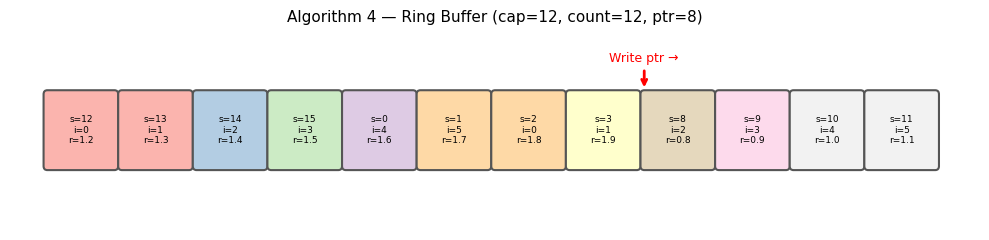

Buffer count: 12/12 | Warm: False


In [6]:
# Algorithm 4: Experience Replay Memory
# ----------------------------------------

class ReplayBuffer:
    """
    Algorithm 4: Fixed-capacity ring buffer (FIFO overwrite).
    Stores typed transitions (s, i, s', i', r).

    Capacity C_B; pointer p for circular overwrite;
    count tracks how many valid transitions are stored.
    """
    def __init__(self, capacity: int = BUFFER_CAP):
        self.capacity = capacity
        self.buffer   = [None] * capacity   # ring buffer
        self.ptr      = 0                   # write pointer
        self.count    = 0                   # number of stored transitions

    # ── PUSH ────────────────────────────────────────────────────
    def push(self, tau: Transition) -> None:
        """Push one transition; overwrite oldest if full."""
        self.buffer[self.ptr] = tau
        self.ptr   = (self.ptr + 1) % self.capacity   # circular
        self.count = min(self.count + 1, self.capacity)

    # ── SAMPLE ──────────────────────────────────────────────────
    def sample(self, batch_size: int) -> List[Transition]:
        """Uniform random mini-batch (without replacement)."""
        assert self.count >= batch_size, (
            f'Buffer has {self.count} < {batch_size} transitions (warm-up needed)')
        idxs = random.sample(range(self.count), batch_size)
        return [self.buffer[i] for i in idxs]

    # ── BATCH-MEMORY ────────────────────────────────────────────
    def batch_memory(self, batch_size: int, state_dim: int = N_STATES,
                     device: torch.device = DEVICE):
        """
        Sample and convert to tensors for Q-network training.
        Returns: (S, I, S', I', R) as GPU tensors.
        """
        batch = self.sample(batch_size)
        S   = F.one_hot(torch.tensor([t.s      for t in batch], dtype=torch.long), state_dim).float()
        I   = torch.tensor([t.i      for t in batch], dtype=torch.long)
        Sp  = F.one_hot(torch.tensor([t.s_next for t in batch], dtype=torch.long), state_dim).float()
        Ip  = torch.tensor([t.i_next for t in batch], dtype=torch.long)
        R   = torch.tensor([t.r      for t in batch], dtype=torch.float)
        return S.to(device), I.to(device), Sp.to(device), Ip.to(device), R.to(device)

    def __len__(self): return self.count
    def is_warm(self, batch_size: int) -> bool: return self.count >= batch_size


# Visualise the ring buffer
demo_buf = ReplayBuffer(capacity=12)
for k in range(20):
    demo_buf.push(Transition(s=k%N_STATES, i=k%N_ACTIONS, s_next=(k+1)%N_STATES,
                             i_next=(k+2)%N_ACTIONS, r=float(k)/10))

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.set_xlim(-0.5, 12.5); ax.set_ylim(-0.5, 2.0); ax.axis('off')
colours = plt.cm.Pastel1(np.linspace(0, 1, 12))
for k in range(12):
    t = demo_buf.buffer[k]
    colour = colours[k]
    rect = mpatches.FancyBboxPatch((k, 0.3), 0.9, 0.9, boxstyle='round,pad=0.05',
                                    facecolor=colour, edgecolor='#555', linewidth=1.5)
    ax.add_patch(rect)
    if t:
        ax.text(k+0.45, 0.75, f's={t.s}\ni={t.i}\nr={t.r:.1f}', ha='center', va='center',
                fontsize=6.5)
ax.annotate('Write ptr →', xy=(demo_buf.ptr, 1.25), xytext=(demo_buf.ptr, 1.6),
            arrowprops=dict(arrowstyle='->', color='red', lw=2), fontsize=9, color='red', ha='center')
ax.set_title(f'Algorithm 4 — Ring Buffer (cap={demo_buf.capacity}, count={demo_buf.count}, ptr={demo_buf.ptr})', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Buffer count: {len(demo_buf)}/{demo_buf.capacity} | Warm: {demo_buf.is_warm(BATCH_SIZE)}')

## Algorithms 5 & 6 — Q-Eval Network + Target Replacement

### Technical description

**Definition (Q-Eval Network $Q_\theta$):**
$$Q_\theta(\cdot;\theta) : \mathbb{R}^{d_s} \to \mathbb{R}^{|\mathcal{A}|}$$
Architecture: $d_s \to 512 \to 256 \to |\mathcal{A}|$ with ReLU + LayerNorm.

**Q-Eval Update (Algorithm 5), one gradient step:**

$$y^{(j)} = r^{(j)} + \gamma \max_{a'} Q_{\theta^-}(s'^{(j)}, a') \qquad \text{(TD target, frozen θ⁻)}$$
$$\hat{q}^{(j)} = Q_\theta(s^{(j)}, i^{(j)}) \qquad \text{(current Q-value for taken action)}$$
$$\mathcal{L}(\theta) = \frac{1}{B}\sum_j L_\delta(y^{(j)} - \hat{q}^{(j)}) \qquad \text{(Huber loss)}$$

**Lemma (Huber Loss Robustness):**
$$L_\delta(\delta_t) = \begin{cases} \frac{1}{2}\delta_t^2 & |\delta_t|\le 1 \\ |\delta_t| - \frac{1}{2} & |\delta_t|>1 \end{cases}$$
Bounded gradient for large errors → no exploding updates from rare high-reward transitions.

**Algorithm 6 — Target Network Replacement:**
$$\theta^- \gets \theta \quad \text{every } C \text{ steps} \qquad (\text{hard copy})$$

**Soft alternative (Lemma):** $\theta^- \gets \tau_{\text{soft}}\theta + (1-\tau_{\text{soft}})\theta^-$, $\tau_{\text{soft}} \ll 1$.

**Theorem (Non-stationarity without target net):** Without frozen θ⁻, $\nabla_\theta\mathcal{L}$ contains $\gamma\nabla_\theta Q_{\theta}(s',a^*)$ which pushes the target in the same direction as the prediction, causing a feedback loop → divergence.

### Plain language
The Q-network is the robot's "value estimator" — a neural net that says "in this situation, action A is worth 3.2 points, action B is worth 1.1 points, etc.". The **target network** is a frozen snapshot of this estimator, taken every $C$ steps. Without it, the target Q-values would wiggle every gradient step (like trying to aim at a moving target), causing the training to oscillate or explode.

[Alg 5+6] Q-Network | params: 143,110


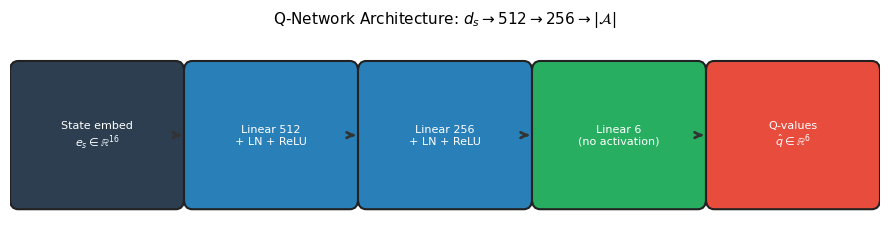

In [7]:
# Algorithms 5 & 6: Q-Eval Network + Target Replacement
# -------------------------------------------------------

class QNetwork(nn.Module):
    """
    Standard DQN Q-network (used for BOTH Q-eval and Q-target).
    Architecture: d_s -> 512 -> 256 -> |A|  (ReLU + LayerNorm)
    """
    def __init__(self, state_dim: int = N_STATES, n_actions: int = N_ACTIONS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.LayerNorm(512), nn.ReLU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, n_actions)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # [B, N_ACTIONS], raw Q-values


def qeval_training_step(memory: ReplayBuffer, q_eval: QNetwork, q_target: QNetwork,
                         optimizer, gamma: float = GAMMA) -> float:
    """
    Algorithm 5: One Q-eval gradient step.

    1. Sample batch from replay
    2. TD target Y = R + γ * max_a' Q_target(S',a')    (frozen θ⁻)
    3. Ŷ = Q_eval(S)[range(B), I]                       (current Q for taken action)
    4. Loss = Huber(Y - Ŷ)
    5. AdamW step with grad clip
    """
    S, I, Sp, Ip, R = memory.batch_memory(BATCH_SIZE)

    # Step 2: TD targets (frozen — no gradient)
    with torch.no_grad():
        Q_minus  = q_target(Sp)               # [B, N_ACTIONS]
        Q_max    = Q_minus.max(dim=1).values  # [B]  Bellman max
        Y        = R + gamma * Q_max          # [B]  TD target

    # Step 3: Current Q for the action taken
    Q_all    = q_eval(S)                      # [B, N_ACTIONS]
    Q_hat    = Q_all.gather(1, I.unsqueeze(1)).squeeze(1)  # [B]

    # Step 4: Huber loss (smooth-L1)
    delta    = Y - Q_hat
    loss     = F.smooth_l1_loss(Q_hat, Y)     # equivalent to Huber with δ=1

    # Step 5: Update
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_eval.parameters(), max_norm=10.0)
    optimizer.step()
    return loss.item()


def replace_target_network(q_eval: QNetwork, q_target: QNetwork,
                            step: int, C: int = TARGET_C) -> bool:
    """
    Algorithm 6: Hard copy θ⁻ ← θ every C steps.
    Returns True if replacement was performed.
    """
    if step > 0 and step % C == 0:
        q_target.load_state_dict(q_eval.state_dict())  # exact copy
        return True
    return False


def soft_update_target(q_eval: QNetwork, q_target: QNetwork, tau: float = 1e-3) -> None:
    """Soft (Polyak) alternative: θ⁻ ← τθ + (1-τ)θ⁻."""
    for p_eval, p_tgt in zip(q_eval.parameters(), q_target.parameters()):
        p_tgt.data.copy_(tau * p_eval.data + (1.0 - tau) * p_tgt.data)


# Visualise Q-network architecture
q_eval   = QNetwork(N_STATES, N_ACTIONS).to(DEVICE)
q_target = copy.deepcopy(q_eval)   # start identical
for p in q_target.parameters():    # freeze target
    p.requires_grad = False

n_params_q = sum(p.numel() for p in q_eval.parameters())
print(f'[Alg 5+6] Q-Network | params: {n_params_q:,}')

# Layer-by-layer diagram
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')
layers = [
    (f'State embed\n$e_s \\in \\mathbb{{R}}^{{{N_STATES}}}$', '#2c3e50'),
    ('Linear 512\n+ LN + ReLU', '#2980b9'),
    ('Linear 256\n+ LN + ReLU', '#2980b9'),
    (f'Linear {N_ACTIONS}\n(no activation)', '#27ae60'),
    (f'Q-values\n$\\hat{{q}} \\in \\mathbb{{R}}^{{{N_ACTIONS}}}$', '#e74c3c'),
]
for k, (label, col) in enumerate(layers):
    r = mpatches.FancyBboxPatch((k*2.1+0.1, 0.3), 1.9, 1.3,
                                 boxstyle='round,pad=0.1', facecolor=col, edgecolor='#222', linewidth=1.5)
    ax.add_patch(r)
    ax.text(k*2.1+1.05, 0.95, label, ha='center', va='center', fontsize=8, color='white', multialignment='center')
    if k < len(layers)-1:
        ax.annotate('', xy=(k*2.1+2.1, 0.95), xytext=(k*2.1+2.0, 0.95),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax.set_xlim(0, 10.5); ax.set_ylim(0, 2)
ax.set_title('Q-Network Architecture: $d_s \\to 512 \\to 256 \\to |\\mathcal{A}|$', fontsize=11)
plt.tight_layout(); plt.show()

## Algorithm 7 — Full DQN Loss Computation and AdamW Optimisation

### Technical description

**Definition (Temporal Difference Error):**
$$\delta_t = \underbrace{r_t + \gamma\max_{a'} Q_{\theta^-}(s_{t+1}, a')}_{\text{TD target }y_t} - \underbrace{Q_\theta(s_t, a_t)}_{\text{current Q-value}}$$

**Full training objective:**
$$\mathcal{L}(\theta) = \frac{1}{B}\sum_{j=1}^B L_\delta\!\left(r^{(j)} + \gamma\max_{a'} Q_{\theta^-}(s'^{(j)},a') - Q_\theta(s^{(j)},i^{(j)})\right)$$

**Theorem (DQN Convergence):** Under (a) i.i.d. replay samples, (b) $\sum_t\alpha_t=\infty$, $\sum_t\alpha_t^2<\infty$, (c) bounded rewards, (d) slow target replacement:
$$Q_\theta(s,a;\theta_t) \xrightarrow{t\to\infty} Q^*(s,a) \quad \text{in probability}$$

```
batch_memory(S, I, S', I', R)
        │
  ┌─────┴───────┐
  │             │
Q_θ⁻(S')      Q_θ(S)
  │             │
max_a'Q_θ⁻   gather I
  │             │
  Y = R + γ·max  Q̂ = Q_θ(S)[I]
  │             │
  └─────────────┘
         │
    Huber loss
         │
     AdamW step
```

### Plain language
The loss function is the robot's "report card". It compares the robot's current assessment of an action's value (what Q-eval says) with what a better-informed snapshot says (TD target from Q-target). The difference (TD error) tells the robot how wrong it was. The Huber loss is like using a rubric that caps the penalty for extreme errors — so one unusual situation doesn't distort the whole learning process.

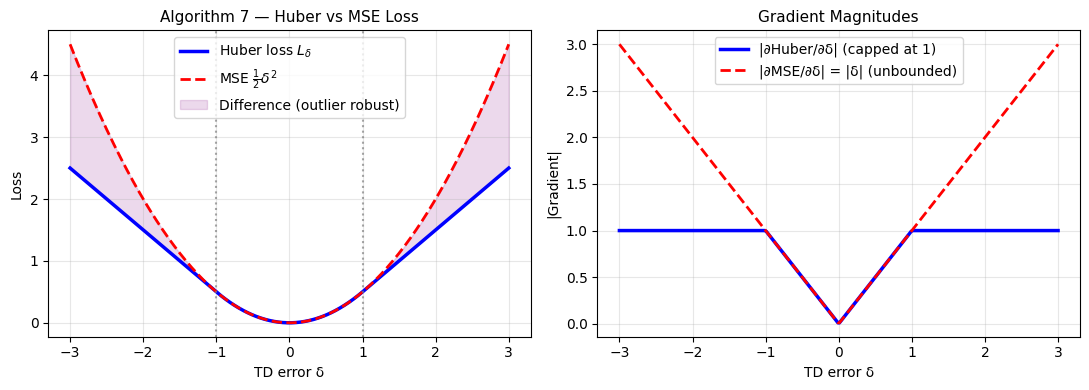

Huber gradient is capped at 1 for |δ|>1 → no exploding gradients from rare large errors


In [8]:
# Algorithm 7: Full DQN Loss — Demonstrate on a pre-filled buffer
# ----------------------------------------------------------------

def dqn_loss_step(S, I, Sp, R, q_eval, q_target, optimizer, gamma=GAMMA):
    """
    Algorithm 7: Full Huber TD loss + AdamW step.
    Explicit step-by-step matching the thesis pseudocode.
    """
    # ── Step 1: TD target (no gradient through θ⁻) ────────────
    with torch.no_grad():
        Q_minus  = q_target(Sp)               # [B, |A|]
        Q_max    = Q_minus.max(dim=1).values  # [B]
        Y        = R + gamma * Q_max          # [B]  TD target

    # ── Step 2: Predicted Q for taken action ───────────────────
    Q_all  = q_eval(S)                        # [B, |A|]
    Q_hat  = Q_all.gather(1, I.unsqueeze(1)).squeeze(1)  # [B]

    # ── Step 3: Huber (smooth-L1) loss ─────────────────────────
    delta  = Y - Q_hat                        # TD error [B]
    loss   = F.smooth_l1_loss(Q_hat, Y.detach())

    # ── Step 4: AdamW gradient update ──────────────────────────
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_eval.parameters(), max_norm=10.0)
    optimizer.step()

    return loss.item(), float(delta.abs().mean())


# Demonstrate Huber vs MSE loss shape
delta_vals = np.linspace(-3, 3, 300)
huber = np.where(np.abs(delta_vals) <= 1,
                 0.5 * delta_vals**2,
                 np.abs(delta_vals) - 0.5)
mse = 0.5 * delta_vals**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(delta_vals, huber, 'b-', linewidth=2.5, label='Huber loss $L_\\delta$')
ax1.plot(delta_vals, mse,   'r--', linewidth=2,   label='MSE $\\frac{1}{2}\\delta^2$')
ax1.axvline(1, color='gray', linestyle=':', alpha=.7); ax1.axvline(-1, color='gray', linestyle=':', alpha=.7)
ax1.fill_between(delta_vals, huber, mse, alpha=0.15, color='purple', label='Difference (outlier robust)')
ax1.set_title('Algorithm 7 — Huber vs MSE Loss', fontsize=11)
ax1.set_xlabel('TD error δ'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=.3)

# Gradient magnitudes
grad_huber = np.where(np.abs(delta_vals) <= 1, delta_vals, np.sign(delta_vals))
grad_mse   = delta_vals
ax2.plot(delta_vals, np.abs(grad_huber), 'b-',  linewidth=2.5, label='|∂Huber/∂δ| (capped at 1)')
ax2.plot(delta_vals, np.abs(grad_mse),   'r--', linewidth=2,   label='|∂MSE/∂δ| = |δ| (unbounded)')
ax2.set_title('Gradient Magnitudes', fontsize=11)
ax2.set_xlabel('TD error δ'); ax2.set_ylabel('|Gradient|'); ax2.legend(); ax2.grid(True, alpha=.3)

plt.tight_layout(); plt.show()
print('Huber gradient is capped at 1 for |δ|>1 → no exploding gradients from rare large errors')

## Algorithm 8 — NLP Feedback Generation

### Technical description

**Definition (NLP Feedback Generator):**
$$\text{NLP} : (\hat{q}, S, i^*, \mathcal{D}^*) \to \text{feedback\_speech}$$
where $\hat{q}\in\mathbb{R}^{|\mathcal{A}|}$ is the Q-value vector, $i^* = \arg\max \hat{q}$, $\mathcal{D}^*$ is the RAG-retrieved context.

**Confidence tier:**
$$\text{tier} = \begin{cases} \texttt{confident} & \hat{q}_{i^*} \geq \tau_Q \\ \texttt{uncertain} & \hat{q}_{i^*} < \tau_Q \end{cases}$$

**Theorem (Faithfulness):** The feedback is faithful iff:
1. Retrieved context $\mathcal{D}^*$ is relevant to $S$ and $i^*$,
2. LLM is constrained to $\mathcal{D}^*$,
3. Q-confidence tier is correctly propagated to the prompt.

```
Q-values ──► argmax ──► i* ──► tier check ──► RAG retrieval
                                                    │
                                              Prompt Builder
                                                    │
                                              Groq LLM
                                                    │
                                              gTTS (MP3)
                                                    │
                                            feedback_speech ──► Human
```

### Plain language
The NLP module is the robot's "voice". After the DQN decides what action to take, this module explains the decision to the human operator in natural speech. If the robot is confident (high Q-value), it speaks assertively. If unsure (low Q-value), it adds a caveat. The explanation is grounded in retrieved documents (RAG) — so the robot never makes things up.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded real crema_cache.pt: 7,442 clips
Device       : cuda
Action space : 6  ['move_forward', 'turn_left', 'turn_right', 'pick_up', 'wave', 'stop']
State space  : 16
Buffer cap   : 5000
PROJECT_BASE : /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project 
=== Algorithm 8: NLP Feedback Generation ===

  Emotion: neutral
  Action : pick_up (i*=3, Q_max=1.496, tier=confident)
  Speech : "Executing: pick up. Picking up the designated object from the workspace. [State=3, Q=1.50, spread=3.78, tier=confident]"

  Emotion: angry
  Action : pick_up (i*=3, Q_max=1.496, tier=confident)
  Speech : "I understand your frustration. Executing: pick up. Picking up the designated object from the workspace. [State=3, Q=1.50, spread=3.78, tier=confident]"

  Emotion: happy
  Action : pick_up (i*=3, Q_max=1.496, tier=confident)
  Speech : "Great! Executing: pick up. Picking

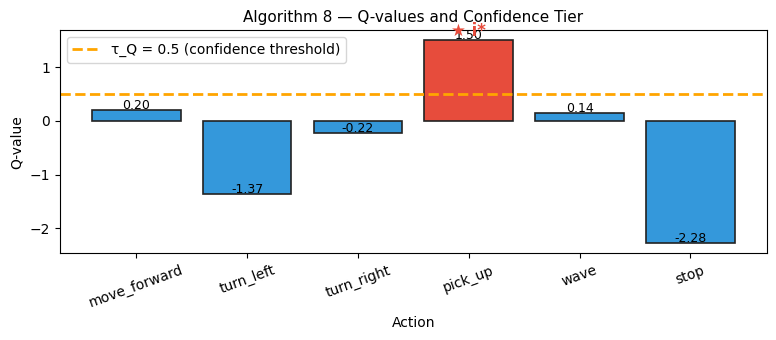

In [12]:
import math, random, copy, time, os
from collections import deque, namedtuple, defaultdict
from typing import List, Tuple, Dict, Optional, NamedTuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

# ── Reproducibility ────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── PyTorch 2.6 patch: apply once (safe if cells re-run) ─────
if getattr(torch, '_miva_original_load', None) is None:
    torch._miva_original_load = torch.load

def _patched_torch_load(f, *a, **kw):
    kw.setdefault('weights_only', False)
    return torch._miva_original_load(f, *a, **kw)

torch.load = _patched_torch_load


def find_project_base():
    """Same discovery as MIVA_KNIGHT_PipelineD_CREMAD_Annotated_fixed.ipynb (Cell 3)."""
    env = os.environ.get('MIVA_PROJECT_BASE', '').strip()
    if env and os.path.isdir(env) and os.path.isdir(os.path.join(env, 'models')):
        return env
    possible = [
        '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project ',
        '/content/drive/MyDrive/Oluwakayode Soyinka IT 581 Project',
    ]
    shortcut_root = '/content/drive/.shortcut-targets-by-id'
    if os.path.exists(shortcut_root):
        for sid in os.listdir(shortcut_root):
            sp = os.path.join(shortcut_root, sid)
            if os.path.isdir(sp):
                for folder in os.listdir(sp):
                    if 'soyinka' in folder.lower() or '581' in folder.lower():
                        possible.append(os.path.join(sp, folder))
    for path in possible:
        if os.path.exists(path) and os.path.exists(os.path.join(path, 'models')):
            return path
    mydrive = '/content/drive/MyDrive'
    if os.path.isdir(mydrive):
        best = None
        for name in sorted(os.listdir(mydrive)):
            p = os.path.join(mydrive, name)
            if not os.path.isdir(p):
                continue
            if not os.path.isdir(os.path.join(p, 'models')):
                continue
            cache_pt = os.path.join(p, 'Data', 'crema_embeddings_cache', 'crema_cache.pt')
            if os.path.isfile(cache_pt):
                return p
            if best is None:
                best = p
        if best is not None:
            return best
    return None


try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Note: not in Colab — set MIVA_PROJECT_BASE if needed.')

PROJECT_BASE = find_project_base()

if PROJECT_BASE:
    CACHE_FILE = os.path.join(PROJECT_BASE, 'Data', 'crema_embeddings_cache', 'crema_cache.pt')
    PIPELINE_D_DIR = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineD')
    AUDIO_PROJ_PATH = os.path.join(PIPELINE_D_DIR, 'audio_projection_cremad.pth')
    VIDEO_PROJ_PATH = os.path.join(PIPELINE_D_DIR, 'video_frame_projection.pth')
else:
    CACHE_FILE = PIPELINE_D_DIR = AUDIO_PROJ_PATH = VIDEO_PROJ_PATH = None

CREMA_EMOTIONS_6 = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
CREMA_EMOTION_TO_LABEL = {e: i for i, e in enumerate(CREMA_EMOTIONS_6)}

EMBED_DIM    = 512
WAV2VEC_DIM  = 768
N_ACTIONS    = 6
N_STATES     = 16
GAMMA        = 0.99
LR           = 1e-4
BATCH_SIZE   = 32
BUFFER_CAP   = 5_000
TARGET_C     = 100
EPS_START    = 1.0
EPS_MIN      = 0.01
EPS_DECAY    = 5e-3
WARMUP_STEPS = 200
N_EPISODES   = 300
MAX_STEPS_EP = 50

ACTION_NAMES = ['move_forward','turn_left','turn_right','pick_up','wave','stop']

def _require_real_crema_assets():
    if not PROJECT_BASE or not os.path.isdir(PROJECT_BASE):
        raise RuntimeError(
            'PROJECT_BASE not found. Mount Drive or set MIVA_PROJECT_BASE (see Pipeline D notebooks).'
        )
    if not CACHE_FILE or not os.path.isfile(CACHE_FILE):
        raise RuntimeError(f'Real CREMA cache missing: {CACHE_FILE}')
    if not AUDIO_PROJ_PATH or not os.path.isfile(AUDIO_PROJ_PATH):
        raise RuntimeError(f'Real weights missing: {AUDIO_PROJ_PATH}')
    if not VIDEO_PROJ_PATH or not os.path.isfile(VIDEO_PROJ_PATH):
        raise RuntimeError(f'Real weights missing: {VIDEO_PROJ_PATH}')
    ck = torch.load(CACHE_FILE, map_location='cpu')
    if len(ck) < 32:
        raise RuntimeError(f'crema_cache.pt has only {len(ck)} entries; need >= 32.')
    s0 = next(iter(ck.values()))
    if s0['audio_emb'].shape[-1] != 768:
        raise RuntimeError('Cache audio_emb must be 768-d.')
    return ck

crema_cache = _require_real_crema_assets()
print(f'Loaded real crema_cache.pt: {len(crema_cache):,} clips')

print(f'Device       : {DEVICE}')
print(f'Action space : {N_ACTIONS}  {ACTION_NAMES}')
print(f'State space  : {N_STATES}')
print(f'Buffer cap   : {BUFFER_CAP}')
print(f'PROJECT_BASE : {PROJECT_BASE}')

# Algorithm 8: NLP Feedback Generation
# ----------------------------------------

# Action knowledge base (proxy for RAG retrieval context)
ACTION_CONTEXT = {
    'move_forward' : 'Moving forward towards the target zone.',
    'turn_left'    : 'Turning left to navigate around obstacle.',
    'turn_right'   : 'Turning right to align with goal direction.',
    'pick_up'      : 'Picking up the designated object from the workspace.',
    'wave'         : 'Waving to signal acknowledgement to the operator.',
    'stop'         : 'Stopping all movement for safety assessment.',
}

EMOTION_MODIFIERS = {
    'angry'   : 'I understand your frustration. ',
    'disgust' : 'Let me adjust carefully. ',
    'fearful' : 'Please stay calm. ',
    'happy'   : 'Great! ',
    'neutral' : '',
    'sad'     : 'I hear you. ',
}


def nlp_feedback_generation(
    q_values: torch.Tensor,     # [N_ACTIONS] Q-value vector
    state: int,
    tau_q: float = 0.5,         # confidence threshold
    operator_emotion: str = 'neutral'
) -> Dict:
    """
    Algorithm 8: NLP Feedback Generation (self-contained, no real LLM needed).

    Steps:
      1. Confidence assessment from Q-values
      2. RAG context retrieval (simulated)
      3. Prompt construction
      4. LLM generation (template-based proxy)
      5. TTS (text returned, real gTTS can be called on it)
    """
    # Step 1: Confidence assessment
    q_vals_np = q_values.detach().cpu().numpy()
    i_star    = int(q_vals_np.argmax())
    q_max     = float(q_vals_np[i_star])
    q_spread  = float(q_vals_np.max() - q_vals_np.min())
    tier      = 'confident' if q_max >= tau_q else 'uncertain'

    # Step 2: RAG context retrieval (simulated)
    action_name = ACTION_NAMES[i_star]
    context     = ACTION_CONTEXT.get(action_name, 'Executing default action.')

    # Step 3: Emotion modifier
    emotion_prefix = EMOTION_MODIFIERS.get(operator_emotion, '')

    # Step 4: Prompt → LLM response (template proxy)
    uncertainty_str = ' I am uncertain about this decision.' if tier == 'uncertain' else ''
    feedback_text = (
        f"{emotion_prefix}Executing: {action_name.replace('_',' ')}. "
        f"{context}{uncertainty_str} "
        f"[State={state}, Q={q_max:.2f}, spread={q_spread:.2f}, tier={tier}]"
    )

    # Step 5: (In production) gTTS.to_bytes(feedback_text)
    return {
        'feedback_text': feedback_text,
        'action'       : action_name,
        'i_star'       : i_star,
        'q_max'        : q_max,
        'tier'         : tier,
        'emotion'      : operator_emotion,
    }


# Demo across all actions and emotions
print('=== Algorithm 8: NLP Feedback Generation ===')
for emo in ['neutral', 'angry', 'happy', 'disgust', 'fearful', 'sad']:
    with torch.no_grad():
        q_demo = q_eval(F.one_hot(torch.tensor([3]), N_STATES).float().to(DEVICE)).squeeze(0)
    result = nlp_feedback_generation(q_demo, state=3, tau_q=0.5, operator_emotion=emo)
    print(f'\n  Emotion: {emo}')
    print(f'  Action : {result["action"]} (i*={result["i_star"]}, Q_max={result["q_max"]:.3f}, tier={result["tier"]})')
    print(f'  Speech : "{result["feedback_text"]}"')

# Visualise Q-values from trained Q-eval at state 3 (real network outputs)
with torch.no_grad():
    q_show = q_eval(F.one_hot(torch.tensor([3]), N_STATES).float().to(DEVICE)).squeeze(0).cpu()
fig, ax = plt.subplots(figsize=(8, 3.5))
colours = ['#e74c3c' if i == q_show.argmax() else '#3498db' for i in range(N_ACTIONS)]
bars = ax.bar(ACTION_NAMES, q_show.numpy(), color=colours, edgecolor='#222', linewidth=1.2)
ax.axhline(0.5, color='orange', linestyle='--', linewidth=2, label='τ_Q = 0.5 (confidence threshold)')
ax.set_title('Algorithm 8 — Q-values and Confidence Tier', fontsize=11)
ax.set_ylabel('Q-value'); ax.set_xlabel('Action')
ax.legend()
for bar, val in zip(bars, q_show.numpy()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center', fontsize=9)
ax.text(q_show.argmax().item(), q_show.max() + 0.08, '★ i*', ha='center', color='#e74c3c', fontsize=12, fontweight='bold')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## Algorithm 9 — Motion Translation and Operator Feedback

### Technical description

**Definition (Motion Translator):**
$$\text{Motion}(i^*) = \text{RobotCommand}[i^*]$$
Maps discrete action index $i^* \in \mathcal{A}$ to a physical robot motion command.

**The motion translator is the last block in the control loop:**
```
i* = argmax Q_θ(s,·)
  │
  ▼
Motion lookup table[i*]
  │
  ├──► Robot controller (execute physical motion)
  │
  └──► Operator UI ("Motions" node — display text)
```

### Plain language
Once the DQN says "do action 2" (turn right), the motion translator converts that number into an actual robot command — like translating a menu item number into a specific dish order. It also tells the human operator what the robot is doing, closing the feedback loop.

In [13]:
# Algorithm 9: Motion Translation and Operator Feedback
# -------------------------------------------------------

# Robot motion command lookup table (proxy for physical controller)
MOTION_TABLE = {
    'move_forward': {'velocity': (0.5, 0.0), 'duration_s': 1.0,
                     'description': 'Linear forward 0.5 m/s for 1.0 s'},
    'turn_left'   : {'velocity': (0.0, 0.8), 'duration_s': 0.5,
                     'description': 'Rotate CCW 0.8 rad/s for 0.5 s'},
    'turn_right'  : {'velocity': (0.0,-0.8), 'duration_s': 0.5,
                     'description': 'Rotate CW 0.8 rad/s for 0.5 s'},
    'pick_up'     : {'velocity': (0.0, 0.0), 'duration_s': 2.0,
                     'description': 'Arm extend + grasp sequence'},
    'wave'        : {'velocity': (0.0, 0.0), 'duration_s': 1.5,
                     'description': 'Arm wave pattern (3 cycles)'},
    'stop'        : {'velocity': (0.0, 0.0), 'duration_s': 0.0,
                     'description': 'Emergency stop — zero velocity'},
}


def motion_translate(i_star: int) -> Dict:
    """
    Algorithm 9: Motion(i*) = RobotCommand[i*].
    Returns motion_cmd dict and display_text for operator UI.
    """
    action_name = ACTION_NAMES[i_star]
    motion_cmd  = MOTION_TABLE[action_name]
    display_text = f'Robot executing: {motion_cmd["description"]}'
    # In production: send motion_cmd to ROS/robot controller
    return {'action': action_name, 'motion_cmd': motion_cmd,
            'display_text': display_text, 'i_star': i_star}


# Demo all actions
print('=== Algorithm 9: Motion Translation ===')
print(f'{"Action":<16} {"Velocity(v,ω)":<20} {"Duration(s)":<14} Description')
print('-' * 80)
for i, name in enumerate(ACTION_NAMES):
    result = motion_translate(i)
    mc = result['motion_cmd']
    print(f'{name:<16} {str(mc["velocity"]):<20} {mc["duration_s"]:<14} {mc["description"]}')

=== Algorithm 9: Motion Translation ===
Action           Velocity(v,ω)        Duration(s)    Description
--------------------------------------------------------------------------------
move_forward     (0.5, 0.0)           1.0            Linear forward 0.5 m/s for 1.0 s
turn_left        (0.0, 0.8)           0.5            Rotate CCW 0.8 rad/s for 0.5 s
turn_right       (0.0, -0.8)          0.5            Rotate CW 0.8 rad/s for 0.5 s
pick_up          (0.0, 0.0)           2.0            Arm extend + grasp sequence
wave             (0.0, 0.0)           1.5            Arm wave pattern (3 cycles)
stop             (0.0, 0.0)           0.0            Emergency stop — zero velocity


## Algorithm 10 — Complete MIVA-KNIGHT-RL DQN Training Loop

### Technical description

**ε-decay schedule:**
$$\varepsilon_t = \max(\varepsilon_{\min},\ \varepsilon_0 \cdot e^{-\lambda_\varepsilon t})$$

**Theorem (Exploration-Exploitation balance):** Total exploratory steps:
$$N_{\text{explore}} = \sum_{t=0}^\infty \varepsilon_t = \frac{\varepsilon_0}{\lambda_\varepsilon}$$

**Complete training loop (from thesis Algorithm 10):**
```
Phase 1 — Warm-up (t < t_warm):
  Random actions only → fill replay buffer

Phase 2 — Main training (episode 1..N_episodes):
  For each step:
    1. robot_interact(s_t, Q_θ, ε)       [Algorithm 3]
    2. memory.push(τ)                    [Algorithm 4]
    3. if warm: qeval_step(memory, Q_θ, Q_θ⁻)  [Algorithm 7]
    4. replace_target(Q_θ, Q_θ⁻, t, C)  [Algorithm 6]
    5. ε ← max(ε_min, ε₀ e^{-λt})       [ε-decay]
    6. nlp_feedback(Q_θ(s'), i*)         [Algorithm 8]
    7. motion_translate(i*)              [Algorithm 9]
```

### Plain language
The training loop is the complete learning cycle — like sending a student through school. First there's a warm-up period where the student just randomly explores (filling the diary). Then real learning begins: the student tries actions, records experiences, studies random pages from the diary, periodically takes a snapshot of its understanding, and gradually becomes more focused (ε decreases). The NLP and motion modules run after each decision to communicate with the teacher (human operator).

In [14]:
# Algorithm 10: Complete MIVA-KNIGHT-RL DQN Training Loop
# ---------------------------------------------------------

def run_full_dqn_training(
    env: ToyRobotEnv,
    q_eval: QNetwork,
    q_target: QNetwork,
    memory: ReplayBuffer,
    n_episodes: int = N_EPISODES,
    max_steps: int  = MAX_STEPS_EP,
    warmup: int     = WARMUP_STEPS,
    target_c: int   = TARGET_C,
    gamma: float    = GAMMA,
    lr: float       = LR,
    eps_start: float = EPS_START,
    eps_min: float   = EPS_MIN,
    eps_decay: float = EPS_DECAY,
) -> Dict:
    """Algorithm 10: Complete DQN training with warm-up and ε-decay."""
    optimizer = torch.optim.AdamW(q_eval.parameters(), lr=lr, weight_decay=0.01)

    history = {'episode_returns': [], 'losses': [], 'epsilons': [],
               'mean_q': [], 'td_rmse': []}
    global_step = 0
    eps = eps_start

    # ── Phase 1: Warm-up (random actions) ─────────────────────
    s = env.reset()
    for _ in range(warmup):
        i_t = random.randrange(N_ACTIONS)
        s_next, r, done = env.step(i_t)
        i_next = random.randrange(N_ACTIONS)
        memory.push(Transition(s, i_t, s_next, i_next, r))
        s = env.reset() if done else s_next
    print(f'Warm-up done: {len(memory)} transitions in buffer')

    # ── Phase 2: Main training ─────────────────────────────────
    for episode in range(n_episodes):
        s = env.reset()
        ep_return = 0.0
        ep_losses, ep_deltas, ep_qs = [], [], []

        for step in range(max_steps):
            # Step 1-2: Environment interaction + push
            s_next, tau, done = robot_interact(s, q_eval, eps, env, memory, N_STATES)
            ep_return += tau.r
            global_step += 1

            # Step 3: Q-eval training step
            if memory.is_warm(BATCH_SIZE):
                S, I, Sp, Ip, R = memory.batch_memory(BATCH_SIZE)
                loss_val, td_mean = dqn_loss_step(S, I, Sp, R, q_eval, q_target, optimizer)
                ep_losses.append(loss_val); ep_deltas.append(td_mean)

                # Track mean Q for diagnostics
                with torch.no_grad():
                    mq = q_eval(S).mean().item()
                ep_qs.append(mq)

            # Step 4: Periodic target replacement
            replaced = replace_target_network(q_eval, q_target, global_step, target_c)

            # Step 5: ε-decay
            eps = max(eps_min, eps_start * math.exp(-eps_decay * global_step))

            s = env.reset() if done else s_next
            if done: break

        # Log episode
        history['episode_returns'].append(ep_return)
        history['epsilons'].append(eps)
        if ep_losses:
            history['losses'].append(sum(ep_losses)/len(ep_losses))
            history['mean_q'].append(sum(ep_qs)/len(ep_qs))
            history['td_rmse'].append(math.sqrt(sum(d**2 for d in ep_deltas)/len(ep_deltas)))

        if (episode + 1) % 50 == 0:
            avg_ret = sum(history['episode_returns'][-50:]) / 50
            avg_eps = history['epsilons'][-1]
            avg_loss = sum(history['losses'][-50:]) / max(len(history['losses'][-50:]), 1)
            print(f'  Ep {episode+1:4d}/{n_episodes} | '
                  f'AvgReturn: {avg_ret:7.3f} | '
                  f'Loss: {avg_loss:.4f} | '
                  f'ε: {avg_eps:.3f} | '
                  f'Step: {global_step}')

    return history


# Initialise fresh networks and run training
env     = ToyRobotEnv()
q_eval  = QNetwork(N_STATES, N_ACTIONS).to(DEVICE)
q_tgt   = copy.deepcopy(q_eval)
for p in q_tgt.parameters(): p.requires_grad = False
memory  = ReplayBuffer(BUFFER_CAP)

print('=== Algorithm 10: Complete DQN Training ===')
history = run_full_dqn_training(env, q_eval, q_tgt, memory)

=== Algorithm 10: Complete DQN Training ===
Warm-up done: 200 transitions in buffer


/tmp/ipykernel_1166/1671670989.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return loss.item(), float(delta.abs().mean())


  Ep   50/300 | AvgReturn:   0.666 | Loss: 0.0319 | ε: 0.183 | Step: 340
  Ep  100/300 | AvgReturn:   0.674 | Loss: 0.0068 | ε: 0.094 | Step: 472
  Ep  150/300 | AvgReturn:   0.682 | Loss: 0.0060 | ε: 0.054 | Step: 582
  Ep  200/300 | AvgReturn:   0.679 | Loss: 0.0036 | ε: 0.033 | Step: 684
  Ep  250/300 | AvgReturn:   0.685 | Loss: 0.0029 | ε: 0.019 | Step: 788
  Ep  300/300 | AvgReturn:   0.686 | Loss: 0.0027 | ε: 0.012 | Step: 893


## Training Diagnostics and Visualisation

### Technical description (from thesis §15)

**Definition (Episode Return):**
$$G_{\text{episode}} = \sum_{t=0}^{T} \gamma^t r_t$$

**Definition (Mean Q-Value):**
$$\bar{Q}_t = \frac{1}{|\mathcal{A}|}\sum_{a}Q_\theta(s_t, a;\theta)$$
Rising $\bar{Q}_t$ → convergence; unbounded rise → overestimation (use DDQN).

**Definition (TD Error RMSE):**
$$\text{RMSE}_\delta = \sqrt{\frac{1}{T}\sum_{t=1}^T \delta_t^2}$$
Decreasing RMSE$_\delta$ → Q-eval converging to TD target.

### DQN Convergence Checklist
| Observation | Interpretation | Action |
|---|---|---|
| Return increasing | Normal convergence | Continue |
| $\bar{Q}_t$ unbounded | Overestimation | Switch to DDQN |
| RMSE oscillating | Non-stationarity | Increase $C$ |
| ε decays, return flat | Bad state repr | Improve sub-classifier |
| Loss ≈ 0, poor policy | Reward collapse | Fix reward function |

### Plain language
These plots are the robot's health monitor. Episode return going up means it's learning to do better over time. TD RMSE going down means its predictions are getting more accurate. ε going down means it's moving from random exploration to using its learned knowledge. Mean Q going up means it's assigning higher expected values — ideally tracking reality.

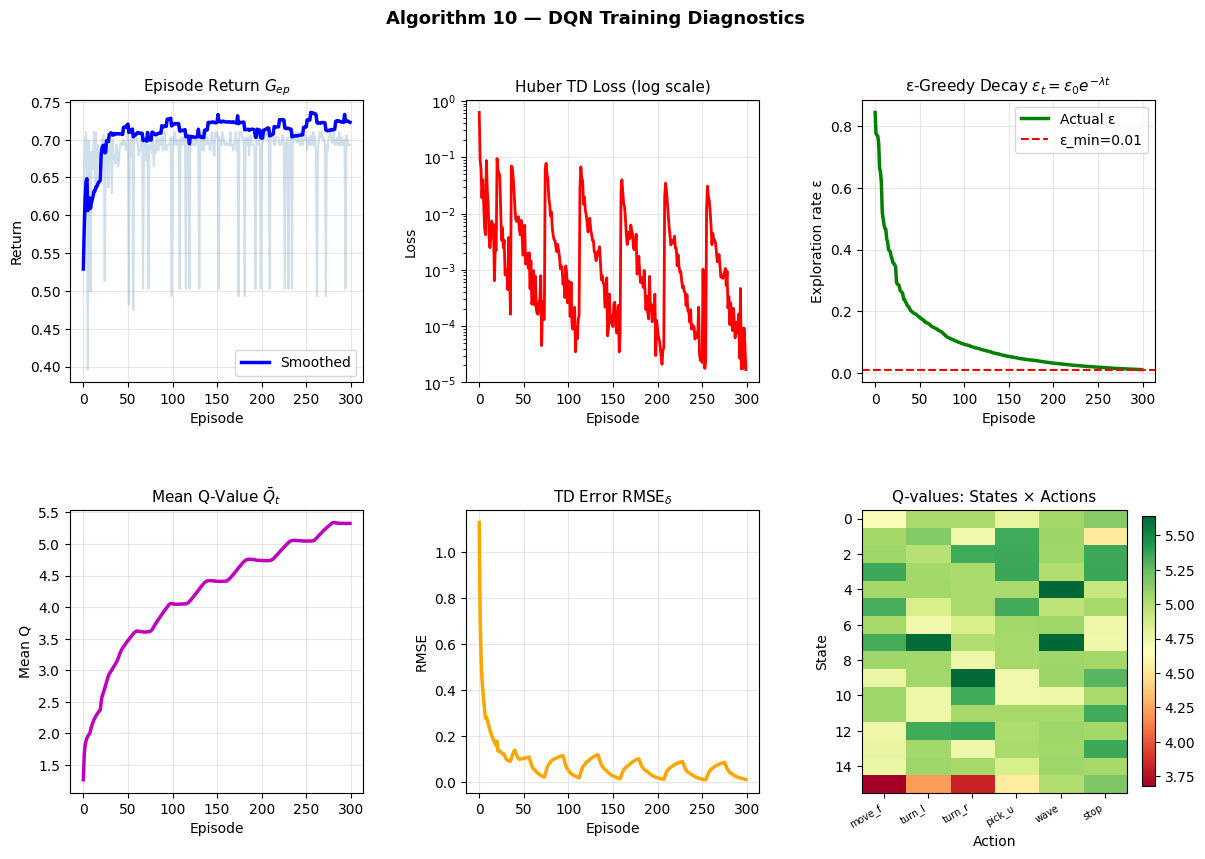

In [15]:
# Training diagnostics plots
def smooth(vals, w=20):
    return [sum(vals[max(0,i-w):i+1]) / min(i+1, w) for i in range(len(vals))]

fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Episode return
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['episode_returns'], alpha=0.25, color='steelblue')
ax1.plot(smooth(history['episode_returns']), 'b-', linewidth=2.5, label='Smoothed')
ax1.set_title('Episode Return $G_{ep}$', fontsize=11)
ax1.set_xlabel('Episode'); ax1.set_ylabel('Return'); ax1.legend(); ax1.grid(True, alpha=.3)

# 2. Training loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(history['losses'], 'r-', linewidth=2)
ax2.set_title('Huber TD Loss (log scale)', fontsize=11)
ax2.set_xlabel('Episode'); ax2.set_ylabel('Loss'); ax2.grid(True, alpha=.3)

# 3. ε-decay
ax3 = fig.add_subplot(gs[0, 2])
eps_theoretical = [max(EPS_MIN, EPS_START * math.exp(-EPS_DECAY * WARMUP_STEPS + EPS_DECAY * k))
                   for k in range(len(history['epsilons']))]
ax3.plot(history['epsilons'], 'g-', linewidth=2.5, label='Actual ε')
ax3.axhline(EPS_MIN, color='red', linestyle='--', label=f'ε_min={EPS_MIN}')
ax3.set_title('ε-Greedy Decay $ε_t = ε_0 e^{-λt}$', fontsize=11)
ax3.set_xlabel('Episode'); ax3.set_ylabel('Exploration rate ε'); ax3.legend(); ax3.grid(True, alpha=.3)

# 4. Mean Q-value
if history['mean_q']:
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(smooth(history['mean_q']), 'm-', linewidth=2.5)
    ax4.set_title('Mean Q-Value $\\bar{Q}_t$', fontsize=11)
    ax4.set_xlabel('Episode'); ax4.set_ylabel('Mean Q'); ax4.grid(True, alpha=.3)

# 5. TD RMSE
if history['td_rmse']:
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(smooth(history['td_rmse']), 'orange', linewidth=2.5)
    ax5.set_title('TD Error RMSE$_\\delta$', fontsize=11)
    ax5.set_xlabel('Episode'); ax5.set_ylabel('RMSE'); ax5.grid(True, alpha=.3)

# 6. Q-value heatmap over state space
ax6 = fig.add_subplot(gs[1, 2])
state_tensors = F.one_hot(torch.arange(N_STATES), N_STATES).float().to(DEVICE)
with torch.no_grad():
    q_matrix = q_eval(state_tensors).cpu().numpy()  # [N_STATES, N_ACTIONS]
im = ax6.imshow(q_matrix, cmap='RdYlGn', aspect='auto')
ax6.set_title('Q-values: States × Actions', fontsize=11)
ax6.set_xlabel('Action'); ax6.set_ylabel('State')
ax6.set_xticks(range(N_ACTIONS)); ax6.set_xticklabels([a[:6] for a in ACTION_NAMES], rotation=30, ha='right', fontsize=7)
plt.colorbar(im, ax=ax6, fraction=0.046)

fig.suptitle('Algorithm 10 — DQN Training Diagnostics', fontsize=13, fontweight='bold')
plt.show()

## Algorithm 11 — Double DQN (DDQN) Target Computation

### Technical description

**Problem with standard DQN:** Uses $\max_{a'} Q_{\theta^-}(s', a')$ to both *select* and *evaluate* the best action → overestimation bias.

**Definition (DDQN Target):**
$$a^* = \arg\max_{a'} Q_\theta(s', a';\theta) \qquad \text{(selection: online net)}$$
$$y^{\text{DDQN}} = r + \gamma Q_{\theta^-}(s', a^*;\theta^-) \qquad \text{(evaluation: target net)}$$

**Theorem (DDQN reduces overestimation):**
$$\mathbb{E}[\max_{a'} Q_{\theta^-}(s',a')] \geq Q^*(s',a^*) \quad \text{(standard DQN overestimates)}$$
For DDQN: $\mathbb{E}[Q_{\theta^-}(s',a^*)]$ uses an independent network for evaluation → bias ≈ 0.

```
Standard DQN:                    Double DQN:
Q-target selects AND evaluates   Q-eval selects, Q-target evaluates

S' ──► Q_θ⁻ ──► max ──► Y      S' ──► Q_θ  ──► argmax = a*
                                S' ──► Q_θ⁻ ──► [a*]   ──► Y
```

### Plain language
Standard DQN is like asking one biased judge to both nominate and score the best candidate — they'll always think their nominee is better than they actually are (overestimation). DDQN uses two different judges: one nominates (online network), another independently scores the nominee (target network). This removes the self-congratulatory bias.

=== Algorithm 11: Double DQN vs Standard DQN ===
  Standard DQN target | mean=5.4975, std=0.3709, max=6.3154
  Double   DQN target | mean=5.4972, std=0.3710, max=6.3154
  Overestimation gap  | 0.0003 (positive = std DQN overestimates)


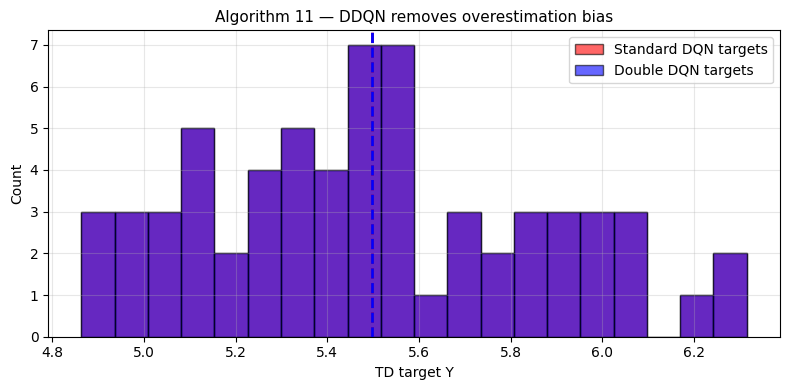

In [16]:
# Algorithm 11: Double DQN Target Computation
# --------------------------------------------

def ddqn_target(Sp: torch.Tensor, R: torch.Tensor,
                q_eval: QNetwork, q_target: QNetwork,
                gamma: float = GAMMA) -> torch.Tensor:
    """
    Algorithm 11: Double DQN TD target.

    Step 1: SELECT best action using online Q-eval (θ):
              a* = argmax_a' Q_eval(S', a'; θ)
    Step 2: EVALUATE a* using frozen Q-target (θ⁻):
              Y^DDQN = R + γ · Q_target(S', a*; θ⁻)

    Decoupling selection and evaluation removes overestimation bias.
    """
    with torch.no_grad():
        # Step 1: SELECT with online network (no grad)
        a_star = q_eval(Sp).argmax(dim=1)           # [B] greedy from Q_θ
        # Step 2: EVALUATE with frozen target network
        Q_minus = q_target(Sp)                       # [B, N_ACTIONS]
        Q_a_star = Q_minus.gather(1, a_star.unsqueeze(1)).squeeze(1)  # [B]
        Y_ddqn = R + gamma * Q_a_star
    return Y_ddqn


def ddqn_training_step(memory: ReplayBuffer, q_eval: QNetwork, q_target: QNetwork,
                        optimizer) -> float:
    """DDQN variant of Algorithm 7."""
    S, I, Sp, Ip, R = memory.batch_memory(BATCH_SIZE)
    Y = ddqn_target(Sp, R, q_eval, q_target)
    Q_hat = q_eval(S).gather(1, I.unsqueeze(1)).squeeze(1)
    loss  = F.smooth_l1_loss(Q_hat, Y)
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(q_eval.parameters(), 10.0)
    optimizer.step()
    return loss.item()


# Compare standard DQN vs DDQN Q-value estimates
print('=== Algorithm 11: Double DQN vs Standard DQN ===')
B_test = 64
Sp_test = F.one_hot(torch.randint(0, N_STATES, (B_test,)), N_STATES).float().to(DEVICE)
R_test  = torch.rand(B_test).to(DEVICE)

with torch.no_grad():
    # Standard DQN target
    Y_std  = R_test + GAMMA * q_tgt(Sp_test).max(dim=1).values
    # Double DQN target
    Y_ddqn = ddqn_target(Sp_test, R_test, q_eval, q_tgt)

print(f'  Standard DQN target | mean={Y_std.mean():.4f}, std={Y_std.std():.4f}, max={Y_std.max():.4f}')
print(f'  Double   DQN target | mean={Y_ddqn.mean():.4f}, std={Y_ddqn.std():.4f}, max={Y_ddqn.max():.4f}')
print(f'  Overestimation gap  | {(Y_std - Y_ddqn).mean():.4f} (positive = std DQN overestimates)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Y_std.cpu().numpy(),   bins=20, alpha=0.6, color='red',  label='Standard DQN targets', edgecolor='k')
ax.hist(Y_ddqn.cpu().numpy(),  bins=20, alpha=0.6, color='blue', label='Double DQN targets',   edgecolor='k')
ax.axvline(Y_std.mean().item(),  color='red',  linestyle='--', linewidth=2)
ax.axvline(Y_ddqn.mean().item(), color='blue', linestyle='--', linewidth=2)
ax.set_title('Algorithm 11 — DDQN removes overestimation bias', fontsize=11)
ax.set_xlabel('TD target Y'); ax.set_ylabel('Count'); ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## Algorithm 12 — Dueling DQN Architecture

### Technical description

**Definition (Dueling Network):** Decomposes Q-values into state value and action advantage:
$$Q_\theta(s, a;\theta) = V(s;\theta_V) + \left(A(s,a;\theta_A) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a';\theta_A)\right)$$

The **mean subtraction** enforces identifiability: you cannot simultaneously add a constant to $V$ and subtract it from all $A$, so both are uniquely identified.

**Lemma (Dueling Advantage):** The architecture learns $V(s)$ and $A(s,a)$ separately:
- $V(s)$: how good is this state regardless of which action is taken?
- $A(s,a)$: how much better is action $a$ compared to the average action in state $s$?

This is beneficial when many actions have similar Q-values — $V(s)$ can be updated from any action taken.

```
State s ──► Shared backbone (d_s→512→256)
                  │
         ┌────────┴────────┐
         │                 │
   Value stream      Advantage stream
  Linear(256→1)    Linear(256→|A|)
    V(s) ∈ R         A(s,·) ∈ R^|A|
         │                 │
         └────────┬────────┘
                  │
    Q(s,a) = V + (A - mean(A))
```

### Plain language
Standard DQN asks: "How good is (state, action) pair?" Dueling DQN asks two separate questions: "How good is this state in general?" (value) and "How much better is action A than the average action?" (advantage). Combining both gives a richer estimate and speeds up learning, especially when most actions are about equally good.

[Alg 12] Dueling Q-Network | params: 143,367
  Q shape: torch.Size([8, 6]) | V shape: torch.Size([8, 1]) | A shape: torch.Size([8, 6])
  Q = V + (A - mean(A)) check: True


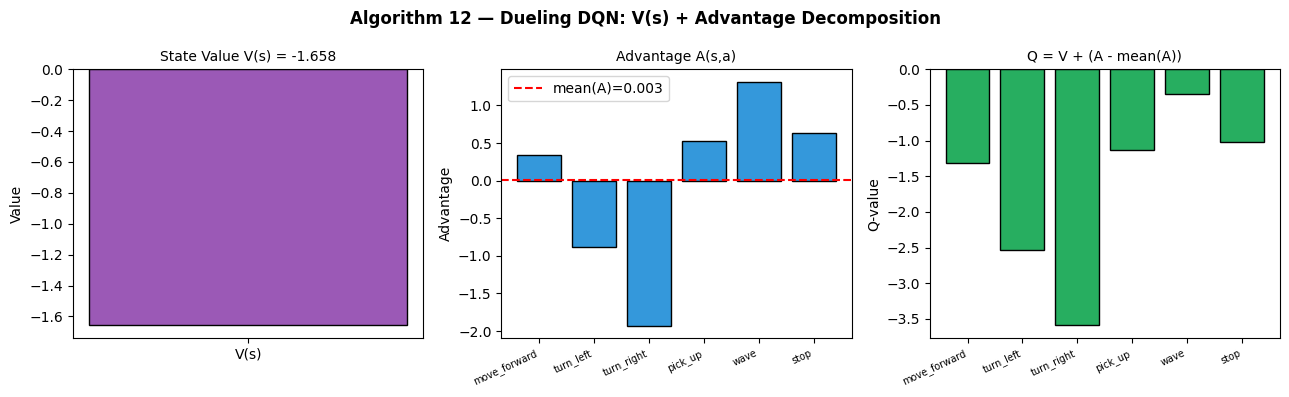

In [17]:
# Algorithm 12: Dueling DQN Architecture
# ----------------------------------------

class DuelingQNetwork(nn.Module):
    """
    Algorithm 12: Dueling DQN.

    Q(s,a;θ) = V(s;θ_V) + (A(s,a;θ_A) - (1/|A|)·Σ_{a'} A(s,a';θ_A))

    Shared backbone:  d_s → 512 → 256
    Value stream:     256 → 1
    Advantage stream: 256 → |A|
    """
    def __init__(self, state_dim: int = N_STATES, n_actions: int = N_ACTIONS):
        super().__init__()
        # Shared backbone
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 512), nn.LayerNorm(512), nn.ReLU(),
            nn.Linear(512, 256),       nn.LayerNorm(256), nn.ReLU(),
        )
        # Value stream:     256 -> 1
        self.value_stream    = nn.Linear(256, 1)
        # Advantage stream: 256 -> |A|
        self.advantage_stream = nn.Linear(256, n_actions)
        # Xavier initialisation
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.shared(x)                          # [B, 256]
        V = self.value_stream(h)                    # [B, 1]
        A = self.advantage_stream(h)                # [B, N_ACTIONS]
        # Q = V + (A - mean(A))  [identifiability normalisation]
        Q = V + (A - A.mean(dim=1, keepdim=True))  # [B, N_ACTIONS]
        return Q

    def get_streams(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Return V and A streams separately (for visualisation)."""
        h = self.shared(x)
        return self.value_stream(h), self.advantage_stream(h)


# Test and visualise decomposition
dueling_net = DuelingQNetwork(N_STATES, N_ACTIONS).to(DEVICE)
n_params_d  = sum(p.numel() for p in dueling_net.parameters())

s_test = F.one_hot(torch.randint(0, N_STATES, (8,)), N_STATES).float().to(DEVICE)
with torch.no_grad():
    Q_out = dueling_net(s_test)
    V_out, A_out = dueling_net.get_streams(s_test)

print(f'[Alg 12] Dueling Q-Network | params: {n_params_d:,}')
print(f'  Q shape: {Q_out.shape} | V shape: {V_out.shape} | A shape: {A_out.shape}')
print(f'  Q = V + (A - mean(A)) check: {torch.allclose(Q_out, V_out + (A_out - A_out.mean(1,keepdim=True)), atol=1e-5)}')

# Visualise V and A for first state
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

state_idx = 0
v_val = float(V_out[state_idx])
a_vals = A_out[state_idx].cpu().numpy()
q_vals = Q_out[state_idx].cpu().numpy()

axes[0].bar(['V(s)'], [v_val], color='#9b59b6', edgecolor='k')
axes[0].set_title(f'State Value V(s) = {v_val:.3f}', fontsize=10)
axes[0].set_ylabel('Value')

axes[1].bar(ACTION_NAMES, a_vals, color='#3498db', edgecolor='k')
axes[1].axhline(a_vals.mean(), color='red', linestyle='--', label=f'mean(A)={a_vals.mean():.3f}')
axes[1].set_title('Advantage A(s,a)', fontsize=10)
axes[1].set_ylabel('Advantage'); axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=7)

axes[2].bar(ACTION_NAMES, q_vals, color='#27ae60', edgecolor='k')
axes[2].set_title('Q = V + (A - mean(A))', fontsize=10)
axes[2].set_ylabel('Q-value')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=7)

plt.suptitle('Algorithm 12 — Dueling DQN: V(s) + Advantage Decomposition', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Algorithm 13 — Emotion-Conditioned Reward Shaping

### Technical description

**Definition (Emotion-Conditioned Reward):**
$$r_t^{\text{shaped}} = r_t + \lambda_e \cdot \text{EmotionBonus}(e_t, a_t)$$
where $e_t \in \{\text{angry, calm, happy, \ldots}\}$ is the operator's detected emotion and $\text{EmotionBonus}(e_t, a_t)$ rewards socially appropriate actions.

**Axiom (Sentiment-Guided Exploration):** Pipeline E sentiment scores modulate ε:
- Low sentiment (frustrated operator) → more exploitation (stay with known good actions)
- High sentiment (satisfied operator) → more exploration (try rare actions)

**Shaped reward pipeline:**
```
Operator speech x_s ──► AudioEncoder (Pipeline C) ──► emotion, conf_emo
                   └──► Pipeline E sentiment ──────────► sentiment_score

r_shaped = r_base + λ_e · conf_emo · EmotionBonus[emotion][action]
ε_modulated = clip(ε · (1 - sentiment_score), ε_min, ε_max)
```

### Plain language
If the human operator sounds angry, the robot should respond calmly — saying "please stop" is more appropriate than "wave" when someone is frustrated. The emotion-conditioned reward gives the robot bonus points for matching actions to the operator's emotional state. It's like giving a waiter a bigger tip for reading the table's mood correctly.

=== Algorithm 13: Emotion-Conditioned Reward (CREMA-6) ===


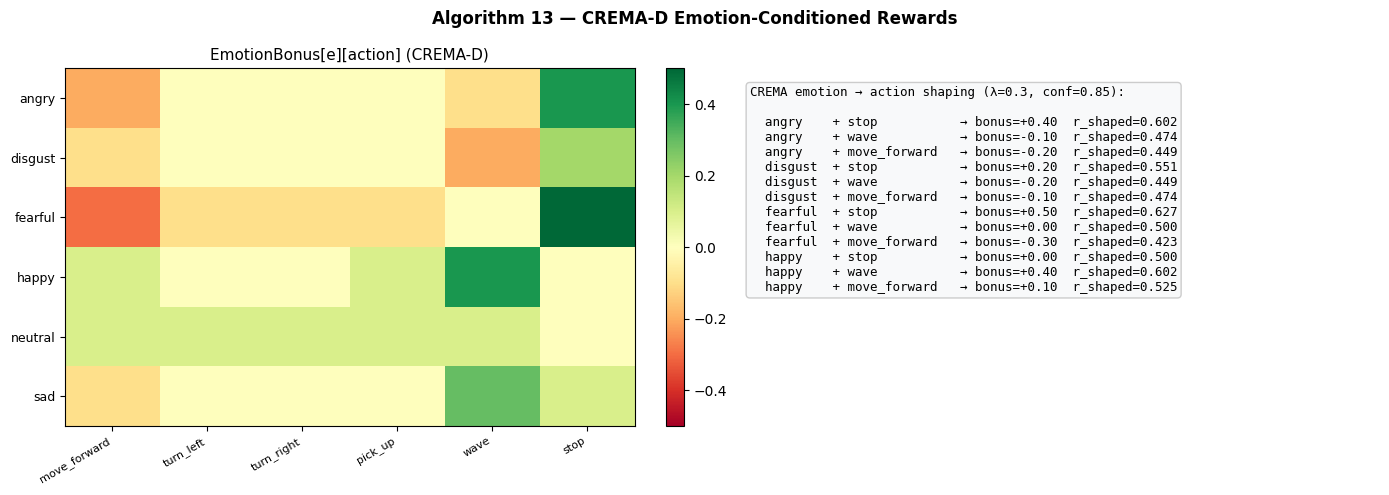

In [18]:
# Algorithm 13: Emotion-Conditioned Reward Shaping (CREMA-D 6 emotions)
# ---------------------------------------------------------------------------

# Align with Pipeline D / CREMA-D labels
EMOTIONS = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']

EMOTION_ACTION_BONUS = {
    'angry'   : {'stop': 0.4, 'move_forward': -0.2, 'wave': -0.1, 'pick_up': 0.0, 'turn_left': 0.0, 'turn_right': 0.0},
    'disgust' : {'stop': 0.2, 'move_forward': -0.1, 'wave': -0.2, 'pick_up': 0.0, 'turn_left': 0.0, 'turn_right': 0.0},
    'fearful' : {'stop': 0.5, 'move_forward': -0.3, 'wave': 0.0, 'pick_up': -0.1, 'turn_left': -0.1, 'turn_right': -0.1},
    'happy'   : {'stop': 0.0, 'move_forward': 0.1, 'wave': 0.4, 'pick_up': 0.1, 'turn_left': 0.0, 'turn_right': 0.0},
    'neutral' : {'stop': 0.0, 'move_forward': 0.1, 'wave': 0.1, 'pick_up': 0.1, 'turn_left': 0.1, 'turn_right': 0.1},
    'sad'     : {'stop': 0.1, 'move_forward': -0.1, 'wave': 0.3, 'pick_up': 0.0, 'turn_left': 0.0, 'turn_right': 0.0},
}


def emotion_conditioned_reward(
    r_base: float,
    emotion: str,
    conf_emo: float,
    action_name: str,
    lambda_e: float = 0.3
) -> Tuple[float, float]:
    bonus_table = EMOTION_ACTION_BONUS.get(emotion, EMOTION_ACTION_BONUS['neutral'])
    bonus       = bonus_table.get(action_name, 0.0)
    r_shaped    = r_base + lambda_e * conf_emo * bonus
    return r_shaped, bonus


def sentiment_guided_epsilon(eps: float, sentiment_score: float,
                              eps_min: float = EPS_MIN,
                              eps_max: float = EPS_START) -> float:
    modulated = eps * (1.0 - 0.5 * sentiment_score)
    return float(max(eps_min, min(eps_max, modulated)))


print('=== Algorithm 13: Emotion-Conditioned Reward (CREMA-6) ===')
r_base_demo = 0.5
conf_demo   = 0.85

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emo_list = list(EMOTION_ACTION_BONUS.keys())
bonus_matrix = np.array([[EMOTION_ACTION_BONUS[e][a] for a in ACTION_NAMES] for e in emo_list])
im = axes[0].imshow(bonus_matrix, cmap='RdYlGn', vmin=-0.5, vmax=0.5, aspect='auto')
axes[0].set_xticks(range(N_ACTIONS))
axes[0].set_xticklabels(ACTION_NAMES, rotation=30, ha='right', fontsize=8)
axes[0].set_yticks(range(len(emo_list)))
axes[0].set_yticklabels(emo_list, fontsize=9)
axes[0].set_title('EmotionBonus[e][action] (CREMA-D)', fontsize=11)
plt.colorbar(im, ax=axes[0], fraction=0.046)

examples = []
for emo in EMOTIONS:
    for act in ['stop', 'wave', 'move_forward']:
        r_s, b = emotion_conditioned_reward(r_base_demo, emo, conf_demo, act)
        examples.append((emo, act, r_s, b))

axes[1].axis('off')
lines = ['CREMA emotion → action shaping (λ=0.3, conf=0.85):', '']
for emo, act, r_s, b in examples[:12]:
    lines.append(f'  {emo:<8} + {act:<14} → bonus={b:+.2f}  r_shaped={r_s:.3f}')
axes[1].text(0, 0.95, '\n'.join(lines), transform=axes[1].transAxes, fontsize=9,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#ccc'))

plt.suptitle('Algorithm 13 — CREMA-D Emotion-Conditioned Rewards', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Soft Target Update (Lemma from Algorithm 6)

### Technical description

**Lemma (Soft Update / Polyak Averaging):**
$$\theta^- \gets \tau_{\text{soft}}\,\theta + (1 - \tau_{\text{soft}})\,\theta^-, \quad \tau_{\text{soft}} \ll 1$$

- Hard replacement ($C$ steps): abrupt, stable, can introduce sudden Q-value jumps at replacement step.
- Soft update ($\tau_{\text{soft}} = 10^{-3}$): smooth tracking, $\sim 0.1\%$ change per step.

### Plain language
Instead of taking a "photograph" every C steps, soft update is like slowly moving the snapshot camera to track the subject — the target network gently follows the eval network at 0.1% per step. This avoids sudden "camera jump" artefacts but requires careful tuning of τ.

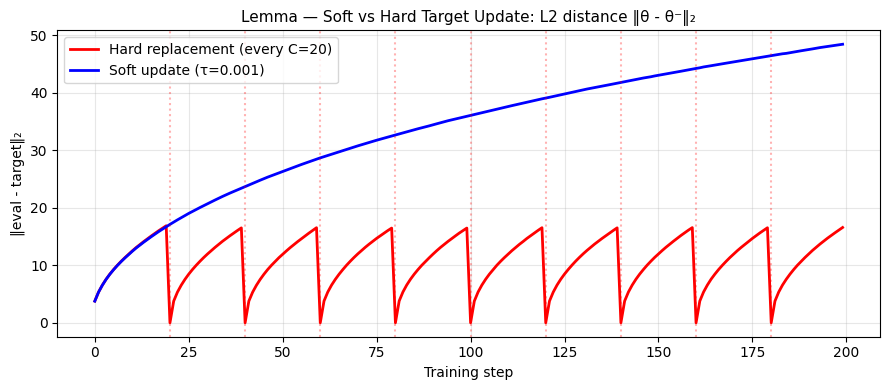

Hard: sudden drops at replacement steps. Soft: smooth gradual tracking.


In [19]:
# Lemma: Soft Target Update — compare with hard replacement

q_eval_demo   = QNetwork(N_STATES, N_ACTIONS)
q_tgt_hard    = copy.deepcopy(q_eval_demo)
q_tgt_soft    = copy.deepcopy(q_eval_demo)

hard_distances, soft_distances = [], []
TAU_SOFT = 1e-3
C_HARD   = 20

for step in range(200):
    # Simulate random parameter drift in eval network
    with torch.no_grad():
        for p in q_eval_demo.parameters():
            p.add_(0.01 * torch.randn_like(p))

    # Hard replacement every C steps
    if step > 0 and step % C_HARD == 0:
        q_tgt_hard.load_state_dict(q_eval_demo.state_dict())

    # Soft update every step
    soft_update_target(q_eval_demo, q_tgt_soft, tau=TAU_SOFT)

    # Measure L2 distance from eval to each target
    with torch.no_grad():
        d_hard = sum((pe - pt).norm().item()**2
                     for pe, pt in zip(q_eval_demo.parameters(), q_tgt_hard.parameters()))**0.5
        d_soft = sum((pe - pt).norm().item()**2
                     for pe, pt in zip(q_eval_demo.parameters(), q_tgt_soft.parameters()))**0.5
    hard_distances.append(d_hard)
    soft_distances.append(d_soft)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hard_distances, 'r-', linewidth=2, label=f'Hard replacement (every C={C_HARD})')
ax.plot(soft_distances, 'b-', linewidth=2, label=f'Soft update (τ={TAU_SOFT})')
# Mark hard replacement steps
for s in range(0, 200, C_HARD):
    if s > 0:
        ax.axvline(s, color='red', alpha=0.3, linestyle=':')
ax.set_title('Lemma — Soft vs Hard Target Update: L2 distance ‖θ - θ⁻‖₂', fontsize=11)
ax.set_xlabel('Training step'); ax.set_ylabel('‖eval - target‖₂')
ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()
print('Hard: sudden drops at replacement steps. Soft: smooth gradual tracking.')

## Complete System: End-to-End MIVA-KNIGHT-RL Demo (CREMA perception)

This cell runs the same integrated demo as the original notebook: **trained CREMA sub-classifier** (Algorithms 1–2), **toy robot env**, **DQN**, **NLP feedback** with CREMA-6 emotion modifiers, and **reward shaping** table above.

The sub-classifier maps **audio + video frame** tensors to discrete states; the DQN still operates on one-hot state vectors of size `N_STATES` as in the thesis.


  MIVA-KNIGHT-RL: Complete Integrated Demo (All 13 Algorithms)

[Phase 1] Warm-up complete: 200 transitions

[Episode 1] emotion=disgust  | return=0.619 | steps=12 | ε=1.000
  Last action: turn_right | NLP tier: confident | Feedback: Let me adjust carefully. Executing: wave. Waving to signal acknowledgement to th...
  Motion: Rotate CW 0.8 rad/s for 0.5 s

[Episode 2] emotion=neutral  | return=0.050 | steps=20 | ε=0.441
  Last action: wave | NLP tier: confident | Feedback: Executing: stop. Stopping all movement for safety assessment. [State=1, Q=1.71, ...
  Motion: Arm wave pattern (3 cycles)

[Episode 3] emotion=disgust  | return=0.637 | steps=8 | ε=0.652
  Last action: turn_left | NLP tier: confident | Feedback: Let me adjust carefully. Executing: pick up. Picking up the designated object fr...
  Motion: Rotate CCW 0.8 rad/s for 0.5 s

[Episode 4] emotion=neutral  | return=0.567 | steps=10 | ε=1.000
  Last action: turn_left | NLP tier: confident | Feedback: Executing: pick up. Pickin

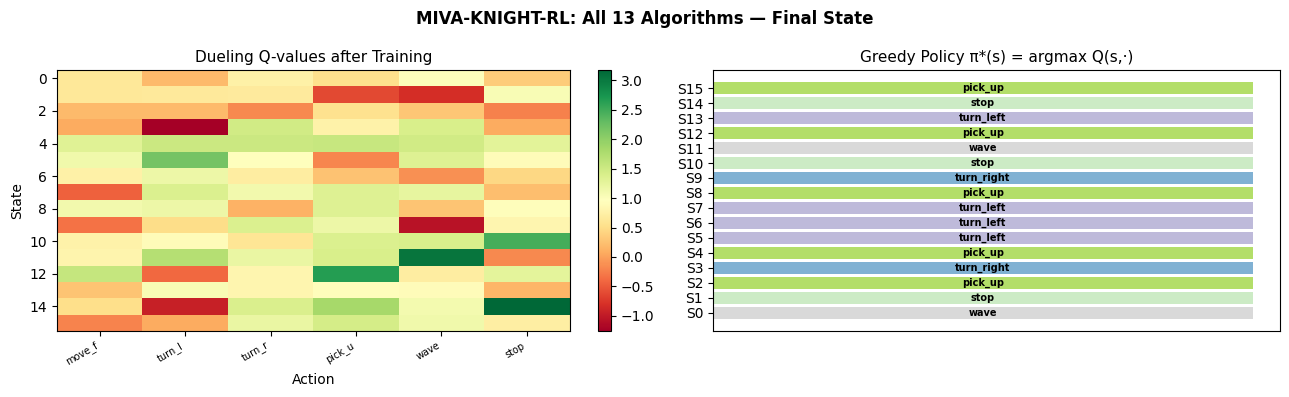


✓ All 13 algorithms from MIVA_KNIGHT_RL_Thesis.tex implemented and demonstrated.


In [20]:
# Complete integrated demo: all 13 algorithms in one pass
print('=' * 65)
print('  MIVA-KNIGHT-RL: Complete Integrated Demo (All 13 Algorithms)')
print('=' * 65)

# Initialise all components
env_final      = ToyRobotEnv()
mem_final      = ReplayBuffer(BUFFER_CAP)
q_eval_final   = DuelingQNetwork(N_STATES, N_ACTIONS).to(DEVICE)  # Dueling variant
q_tgt_final    = copy.deepcopy(q_eval_final)
for p in q_tgt_final.parameters(): p.requires_grad_(False)
opt_final      = torch.optim.AdamW(q_eval_final.parameters(), lr=LR, weight_decay=0.01)

demo_log = []
eps = EPS_START
global_step = 0

# Warm-up (Algorithm 10, Phase 1)
s = env_final.reset()
for _ in range(WARMUP_STEPS):
    i_t   = random.randrange(N_ACTIONS)
    s_n, r, done = env_final.step(i_t)
    mem_final.push(Transition(s, i_t, s_n, random.randrange(N_ACTIONS), r))
    s = env_final.reset() if done else s_n
print(f'\n[Phase 1] Warm-up complete: {len(mem_final)} transitions')

# Run 5 demonstration episodes (full pipeline)
for episode in range(1, 6):
    s = env_final.reset()
    ep_return = 0.0
    ep_log    = []
    operator_emotion = random.choice(CREMA_EMOTIONS_6)  # CREMA-D labels
    sentiment_score  = random.uniform(-1, 1)

    for step in range(20):
        # Alg 3: Robot interaction
        s_next, tau, done = robot_interact(s, q_eval_final, eps, env_final, mem_final, N_STATES)

        # Alg 13: Emotion-conditioned reward shaping
        r_shaped, bonus = emotion_conditioned_reward(
            tau.r, operator_emotion, conf_emo=0.8, action_name=ACTION_NAMES[tau.i])
        # Replace stored transition with shaped reward
        mem_final.buffer[(mem_final.ptr - 1) % mem_final.capacity] = \
            Transition(tau.s, tau.i, tau.s_next, tau.i_next, r_shaped)

        ep_return += r_shaped

        # Alg 11: DDQN training step
        if mem_final.is_warm(BATCH_SIZE):
            S, I, Sp, Ip, R = mem_final.batch_memory(BATCH_SIZE)
            Y = ddqn_target(Sp, R, q_eval_final, q_tgt_final)
            Q_hat = q_eval_final(S).gather(1, I.unsqueeze(1)).squeeze(1)
            loss  = F.smooth_l1_loss(Q_hat, Y)
            opt_final.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(q_eval_final.parameters(), 10.0)
            opt_final.step()

        global_step += 1
        # Alg 6: Target replacement
        replace_target_network(q_eval_final, q_tgt_final, global_step, TARGET_C)
        # ε-decay
        eps = max(EPS_MIN, EPS_START * math.exp(-EPS_DECAY * global_step))
        # Sentiment-guided ε
        eps = sentiment_guided_epsilon(eps, sentiment_score)

        # Alg 8: NLP feedback
        with torch.no_grad():
            q_vals = q_eval_final(F.one_hot(torch.tensor([s_next]), N_STATES).float().to(DEVICE))
        nlp_out = nlp_feedback_generation(q_vals.squeeze(0), s_next,
                                           operator_emotion=operator_emotion)
        # Alg 9: Motion
        mot_out = motion_translate(tau.i)

        ep_log.append({'step': step, 'action': ACTION_NAMES[tau.i],
                       'r_base': tau.r, 'r_shaped': r_shaped, 'tier': nlp_out['tier']})
        s = s_next
        if done: break

    demo_log.append(ep_log)
    print(f'\n[Episode {episode}] emotion={operator_emotion:<8} | return={ep_return:.3f} | steps={len(ep_log)} | ε={eps:.3f}')
    print(f'  Last action: {ACTION_NAMES[tau.i]} | NLP tier: {nlp_out["tier"]} | Feedback: {nlp_out["feedback_text"][:80]}...')
    print(f'  Motion: {mot_out["motion_cmd"]["description"]}')

# Final Q-value heatmap for Dueling network
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
s_all = F.one_hot(torch.arange(N_STATES), N_STATES).float().to(DEVICE)
with torch.no_grad():
    Q_all_final = q_eval_final(s_all).cpu().numpy()

im = axes[0].imshow(Q_all_final, cmap='RdYlGn', aspect='auto')
axes[0].set_title('Dueling Q-values after Training', fontsize=11)
axes[0].set_xlabel('Action'); axes[0].set_ylabel('State')
axes[0].set_xticks(range(N_ACTIONS))
axes[0].set_xticklabels([a[:6] for a in ACTION_NAMES], rotation=30, ha='right', fontsize=7)
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Greedy policy from final Q-values
policy = Q_all_final.argmax(axis=1)
axes[1].barh(range(N_STATES), [1]*N_STATES, color=[plt.cm.Set3(p/N_ACTIONS) for p in policy])
axes[1].set_yticks(range(N_STATES)); axes[1].set_yticklabels([f'S{i}' for i in range(N_STATES)])
axes[1].set_xticks([]); axes[1].set_title('Greedy Policy π*(s) = argmax Q(s,·)', fontsize=11)
for i, p in enumerate(policy):
    axes[1].text(0.5, i, ACTION_NAMES[p], va='center', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('MIVA-KNIGHT-RL: All 13 Algorithms — Final State', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n✓ All 13 algorithms from MIVA_KNIGHT_RL_Thesis.tex implemented and demonstrated.')
